# 嘗試使用tsne畫圖
參考資料：https://www.datatechnotes.com/2020/11/tsne-visualization-example-in-python.html

https://mropengate.blogspot.com/2019/06/t-sne.html

https://github.com/UCL-DSS/Dimensionality_reduction/blob/main/.ipynb_checkpoints/Solutions-checkpoint.ipynb
（程式碼從這裡來）

# 匯入工具

In [ ]:
from sklearn.manifold import TSNE
from keras.datasets import mnist
from numpy import reshape
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df1 = pd.read_csv('/content/PCA_a.csv') #encoding= 'unicode_escape')   #讀取資料
df1.isnull().values  #缺失值
~df1.applymap(np.isreal).values  #非數字
df2 = df1.drop(['Ch01','Ch05','Ch08','Ch09','Ch10','Ch11','Ch12','Ch14','Ch18','Ch19','Ch20','Ch21','Chcolor',
                'Ch06','Ch15','Ch22','Ch24','Ch26'],axis=1)
                #'Ch06','Ch15','Ch22','Ch24','Ch26'],axis=1),'Chcolor' #刪掉一些貢獻性不高的特徵
                #'Ch01 加回來
# print(df2) #只留下定量

data_dum_1 = pd.get_dummies(df2) #data_dum_1留下全部分岔？
data_dum_1 = df2.fillna(df2.mean(numeric_only=True))

print(data_dum_1)
#print(dfonehot)
data_dum_1.head()


              ID  Ch01-1        Ch02  Ch03   Ch04       Ch07  Ch13     Ch16  \
0      2019_0001       1  136.000000   5.2  47.07  18.900000   0.0  8.28000   
1      2019_0002       1   95.200000   3.4  32.87  12.100000   0.0  5.68000   
2      2019_0003       1  120.300000   7.4  42.57  23.600000  21.7  8.66000   
3      2019_0004       1  109.600000   4.2  37.93  15.100000  10.6  7.92000   
4      2019_0005       1  134.800000   5.1  46.63  16.600000   0.0  5.86000   
..           ...     ...         ...   ...    ...        ...   ...      ...   
102  2020_1010_a       5   52.760000   2.4  12.83   8.960000   0.0  7.73515   
103  2020_1011_a       4   54.800000   2.4  14.85   9.150000   0.0  4.85500   
104  2020_1012_a       5   46.300000   3.2  15.13   8.840000   0.0  7.73515   
105  2020_1013_a       3   59.400000   2.4  15.67  10.633333   0.0  5.26000   
106  2020_1015_a       3   82.866667   9.7  24.73  10.433333   0.0  6.10000   

         Ch17  Ch23  Ch25  Ch27  Ch28  Ch29  Ch30  

<ipython-input-49-7573c3074300>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ~df1.applymap(np.isreal).values  #非數字


,ID,Ch01-1,Ch02,Ch03,Ch04,Ch07,Ch13,Ch16,Ch17,Ch23,Ch25,Ch27,Ch28,Ch29,Ch30
0,2019_0001,1,136.0,5.2,47.07,18.9,0.0,8.28,6.96,1.77,0.91,1.26,1.10,0.75,4.06
1,2019_0002,1,95.2,3.4,32.87,12.1,0.0,5.68,0.30,1.89,0.93,1.50,1.18,0.82,4.30
2,2019_0003,1,120.3,7.4,42.57,23.6,21.7,8.66,3.72,1.73,0.97,1.36,1.28,0.90,6.40
3,2019_0004,1,109.6,4.2,37.93,15.1,10.6,7.92,2.69,1.68,0.91,1.27,1.20,0.82,4.40
4,2019_0005,1,134.8,5.1,46.63,16.6,0.0,5.86,1.88,1.70,1.00,1.23,1.19,0.83,3.33


In [ ]:
from scipy.stats import shapiro
X = data_dum_1.iloc[:, 1:].values
shapiro(X)

ShapiroResult(statistic=np.float64(0.4825270175773234), pvalue=np.float64(1.9773981134222655e-54))

In [ ]:
#extract the columns to scale
cols = ['Ch01-1','Ch02','Ch03','Ch04','Ch07','Ch13','Ch17',
        'Ch23','Ch25','Ch27','Ch28','Ch29','Ch30']

#extract the total X variables
X_scaled = data_dum_1

'''
#scale the results using fit_transform
for col in cols:
    X_scaled[col] = sc.fit_transform(X_scaled[col].values.reshape(-1,1))
'''

'\n#scale the results using fit_transform\nfor col in cols:\n    X_scaled[col] = sc.fit_transform(X_scaled[col].values.reshape(-1,1))\n'

要先pca？

[[  1.         136.           5.2        ...   1.1          0.75
    4.06      ]
 [  1.          95.2          3.4        ...   1.18         0.82
    4.3       ]
 [  1.         120.3          7.4        ...   1.28         0.9
    6.4       ]
 ...
 [  5.          46.3          3.2        ...   1.05         0.64
    3.9       ]
 [  3.          59.4          2.4        ...   1.21         0.79
    7.44      ]
 [  3.          82.86666667   9.7        ...   0.91         0.33
    8.37      ]]
[0.28712336 0.18446915 0.11715469 0.076534   0.07324078 0.06560956
 0.04828294 0.04454797 0.02667971 0.02503833 0.01946487 0.01504891
 0.01423518]


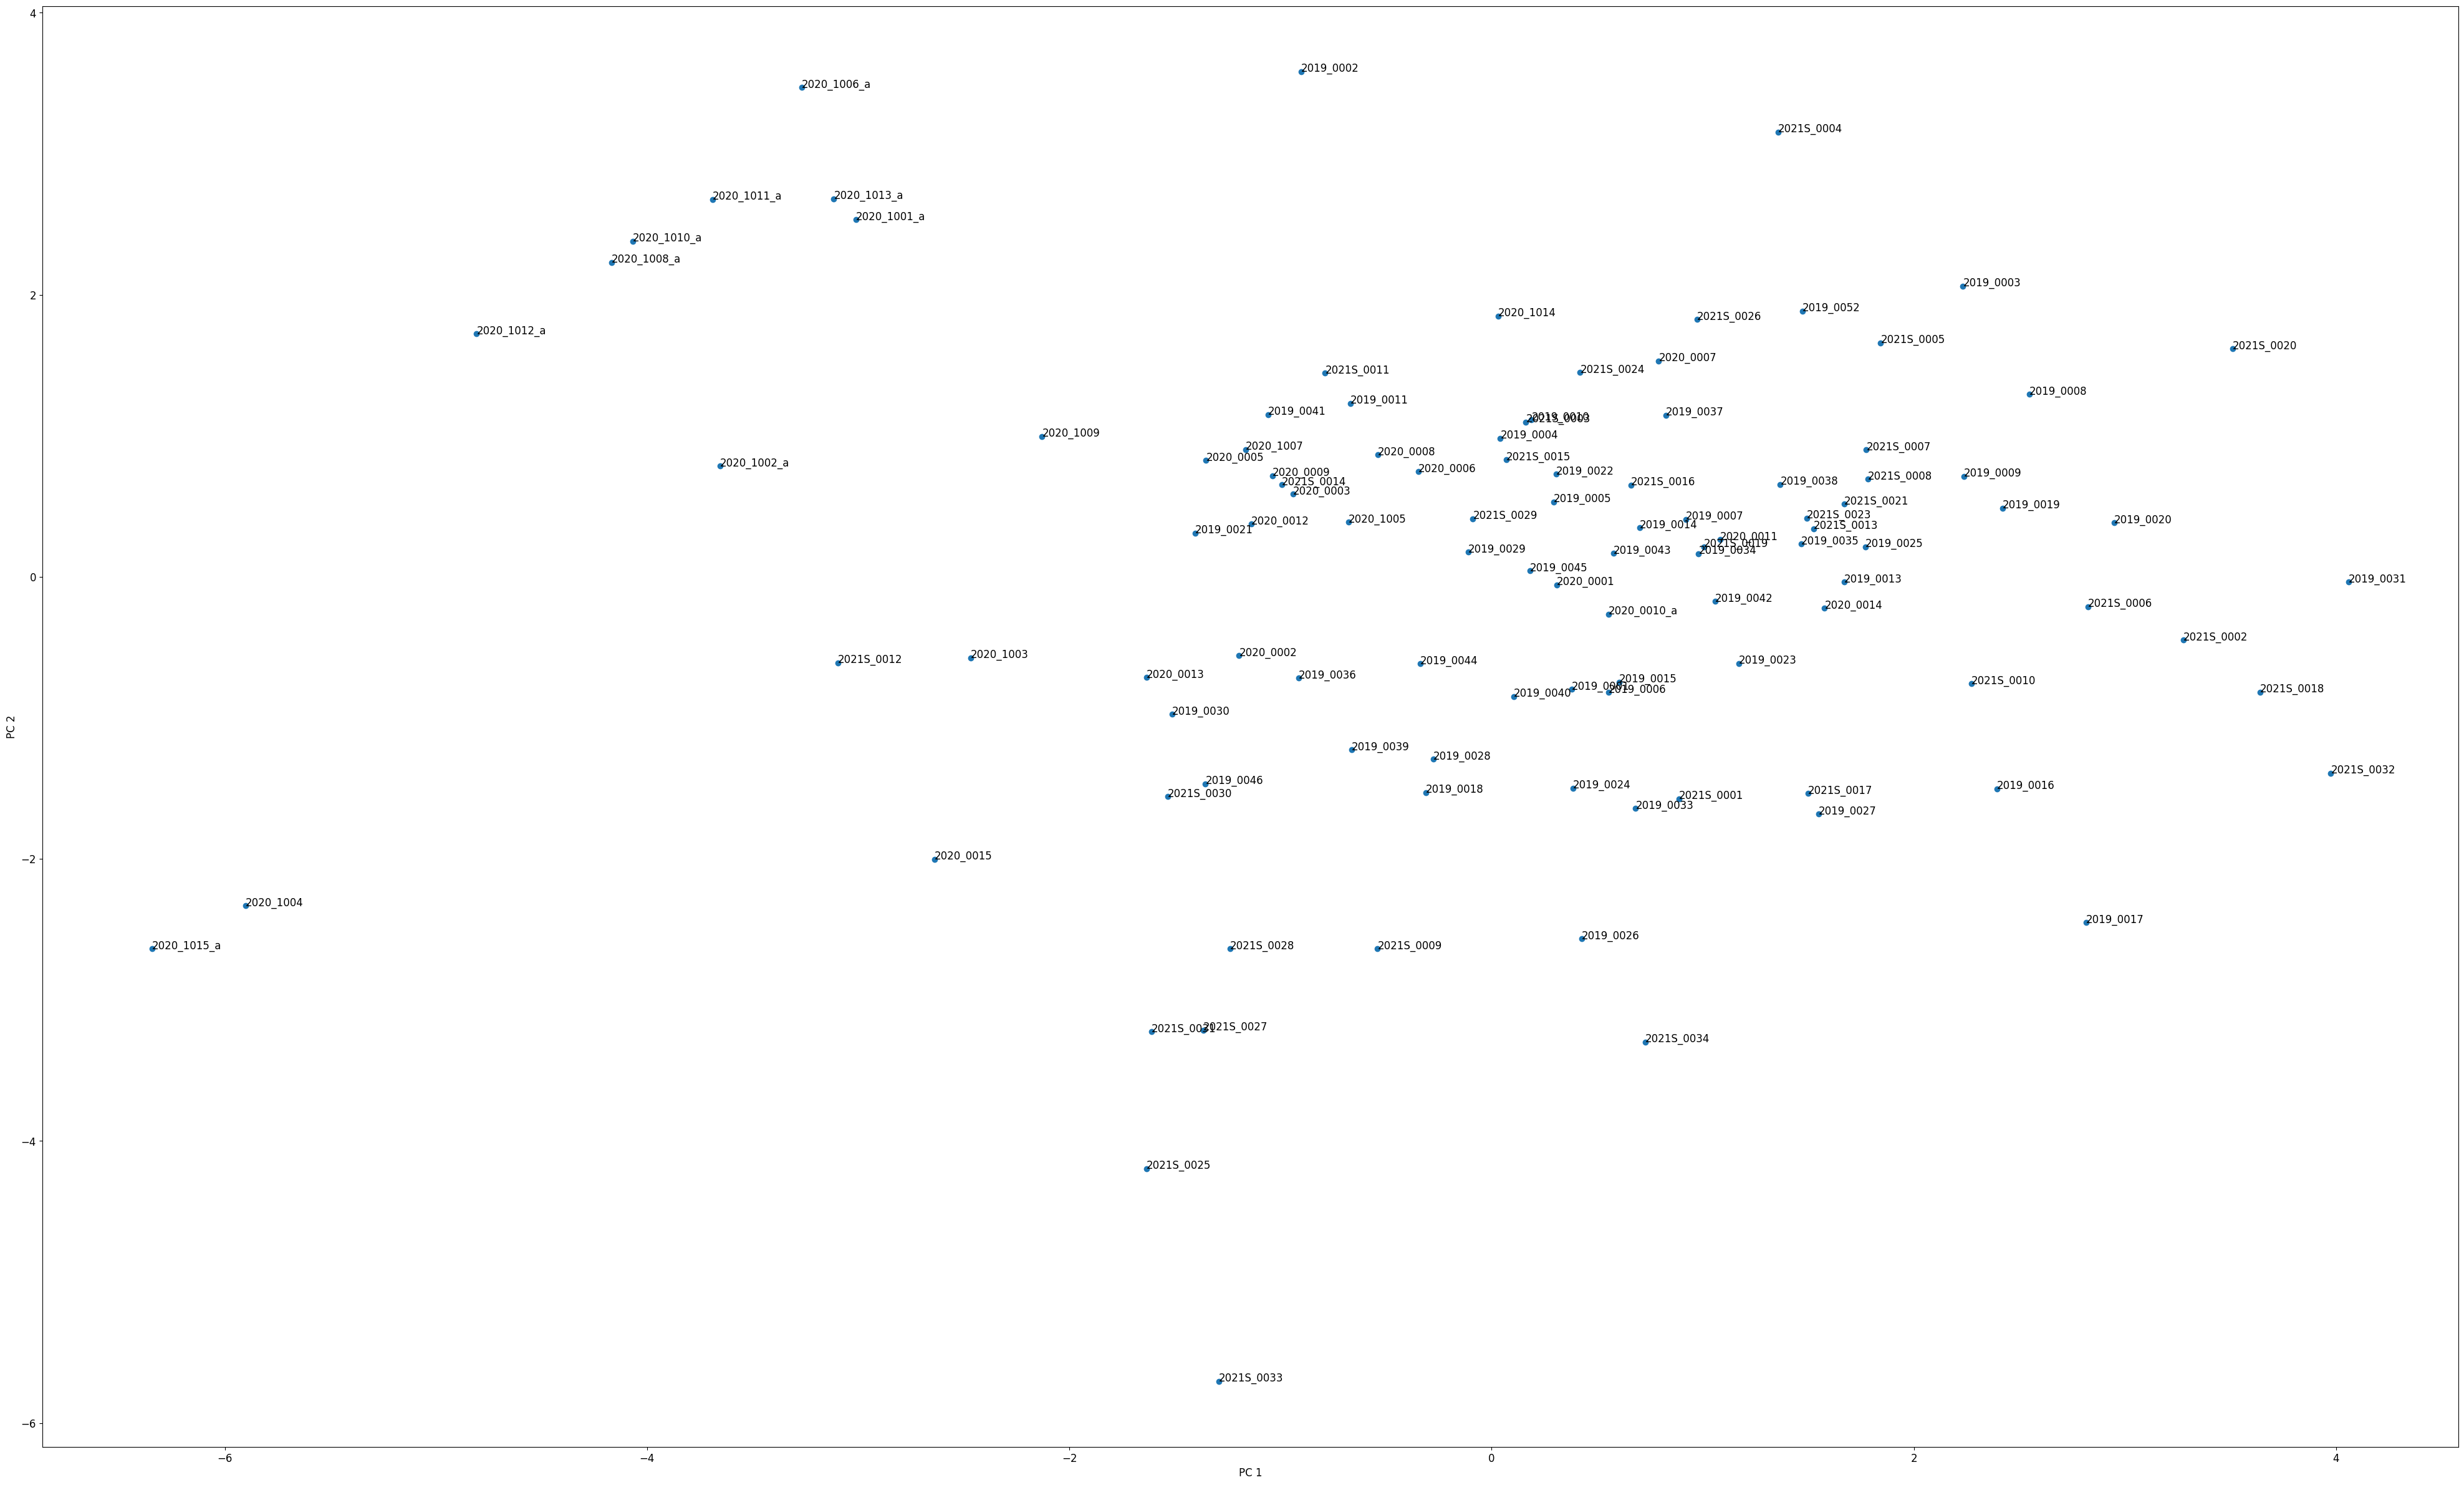

前90%的的PC值（到PC9）: [0.28712336 0.18446915 0.11715469 0.076534   0.07324078 0.06560956
 0.04828294 0.04454797 0.02667971]
特徵向量： [[-0.28291794  0.35238796  0.21911409  0.34256163  0.38373618  0.16252811
   0.28677443  0.15583592  0.00618358  0.3604709   0.10729606  0.29703574
   0.33262886 -0.09932435]
 [ 0.22728193 -0.29758246 -0.13836079 -0.28117618 -0.17491602  0.1118965
  -0.1091039  -0.19671415  0.24121509  0.31333404  0.45994911  0.41952717
   0.35183923 -0.01254123]
 [ 0.01527201  0.03969667  0.40626554  0.02835946  0.08613357  0.24371696
   0.14298529 -0.11853502  0.61428993 -0.30275327  0.36119727 -0.1262073
  -0.32702713 -0.09312645]
 [ 0.23060326 -0.12191737  0.2279248  -0.22672549 -0.0363415   0.55300996
   0.09310862  0.54939494 -0.20300444 -0.04189202 -0.03527652  0.03629121
  -0.00772081  0.40666025]
 [-0.37672922 -0.06023476  0.03749811  0.13760448  0.05214016  0.03491502
  -0.10588127 -0.42474155 -0.00896804 -0.04857197  0.03089348  0.09999964
  -0.02040704  0.79040587]
 [

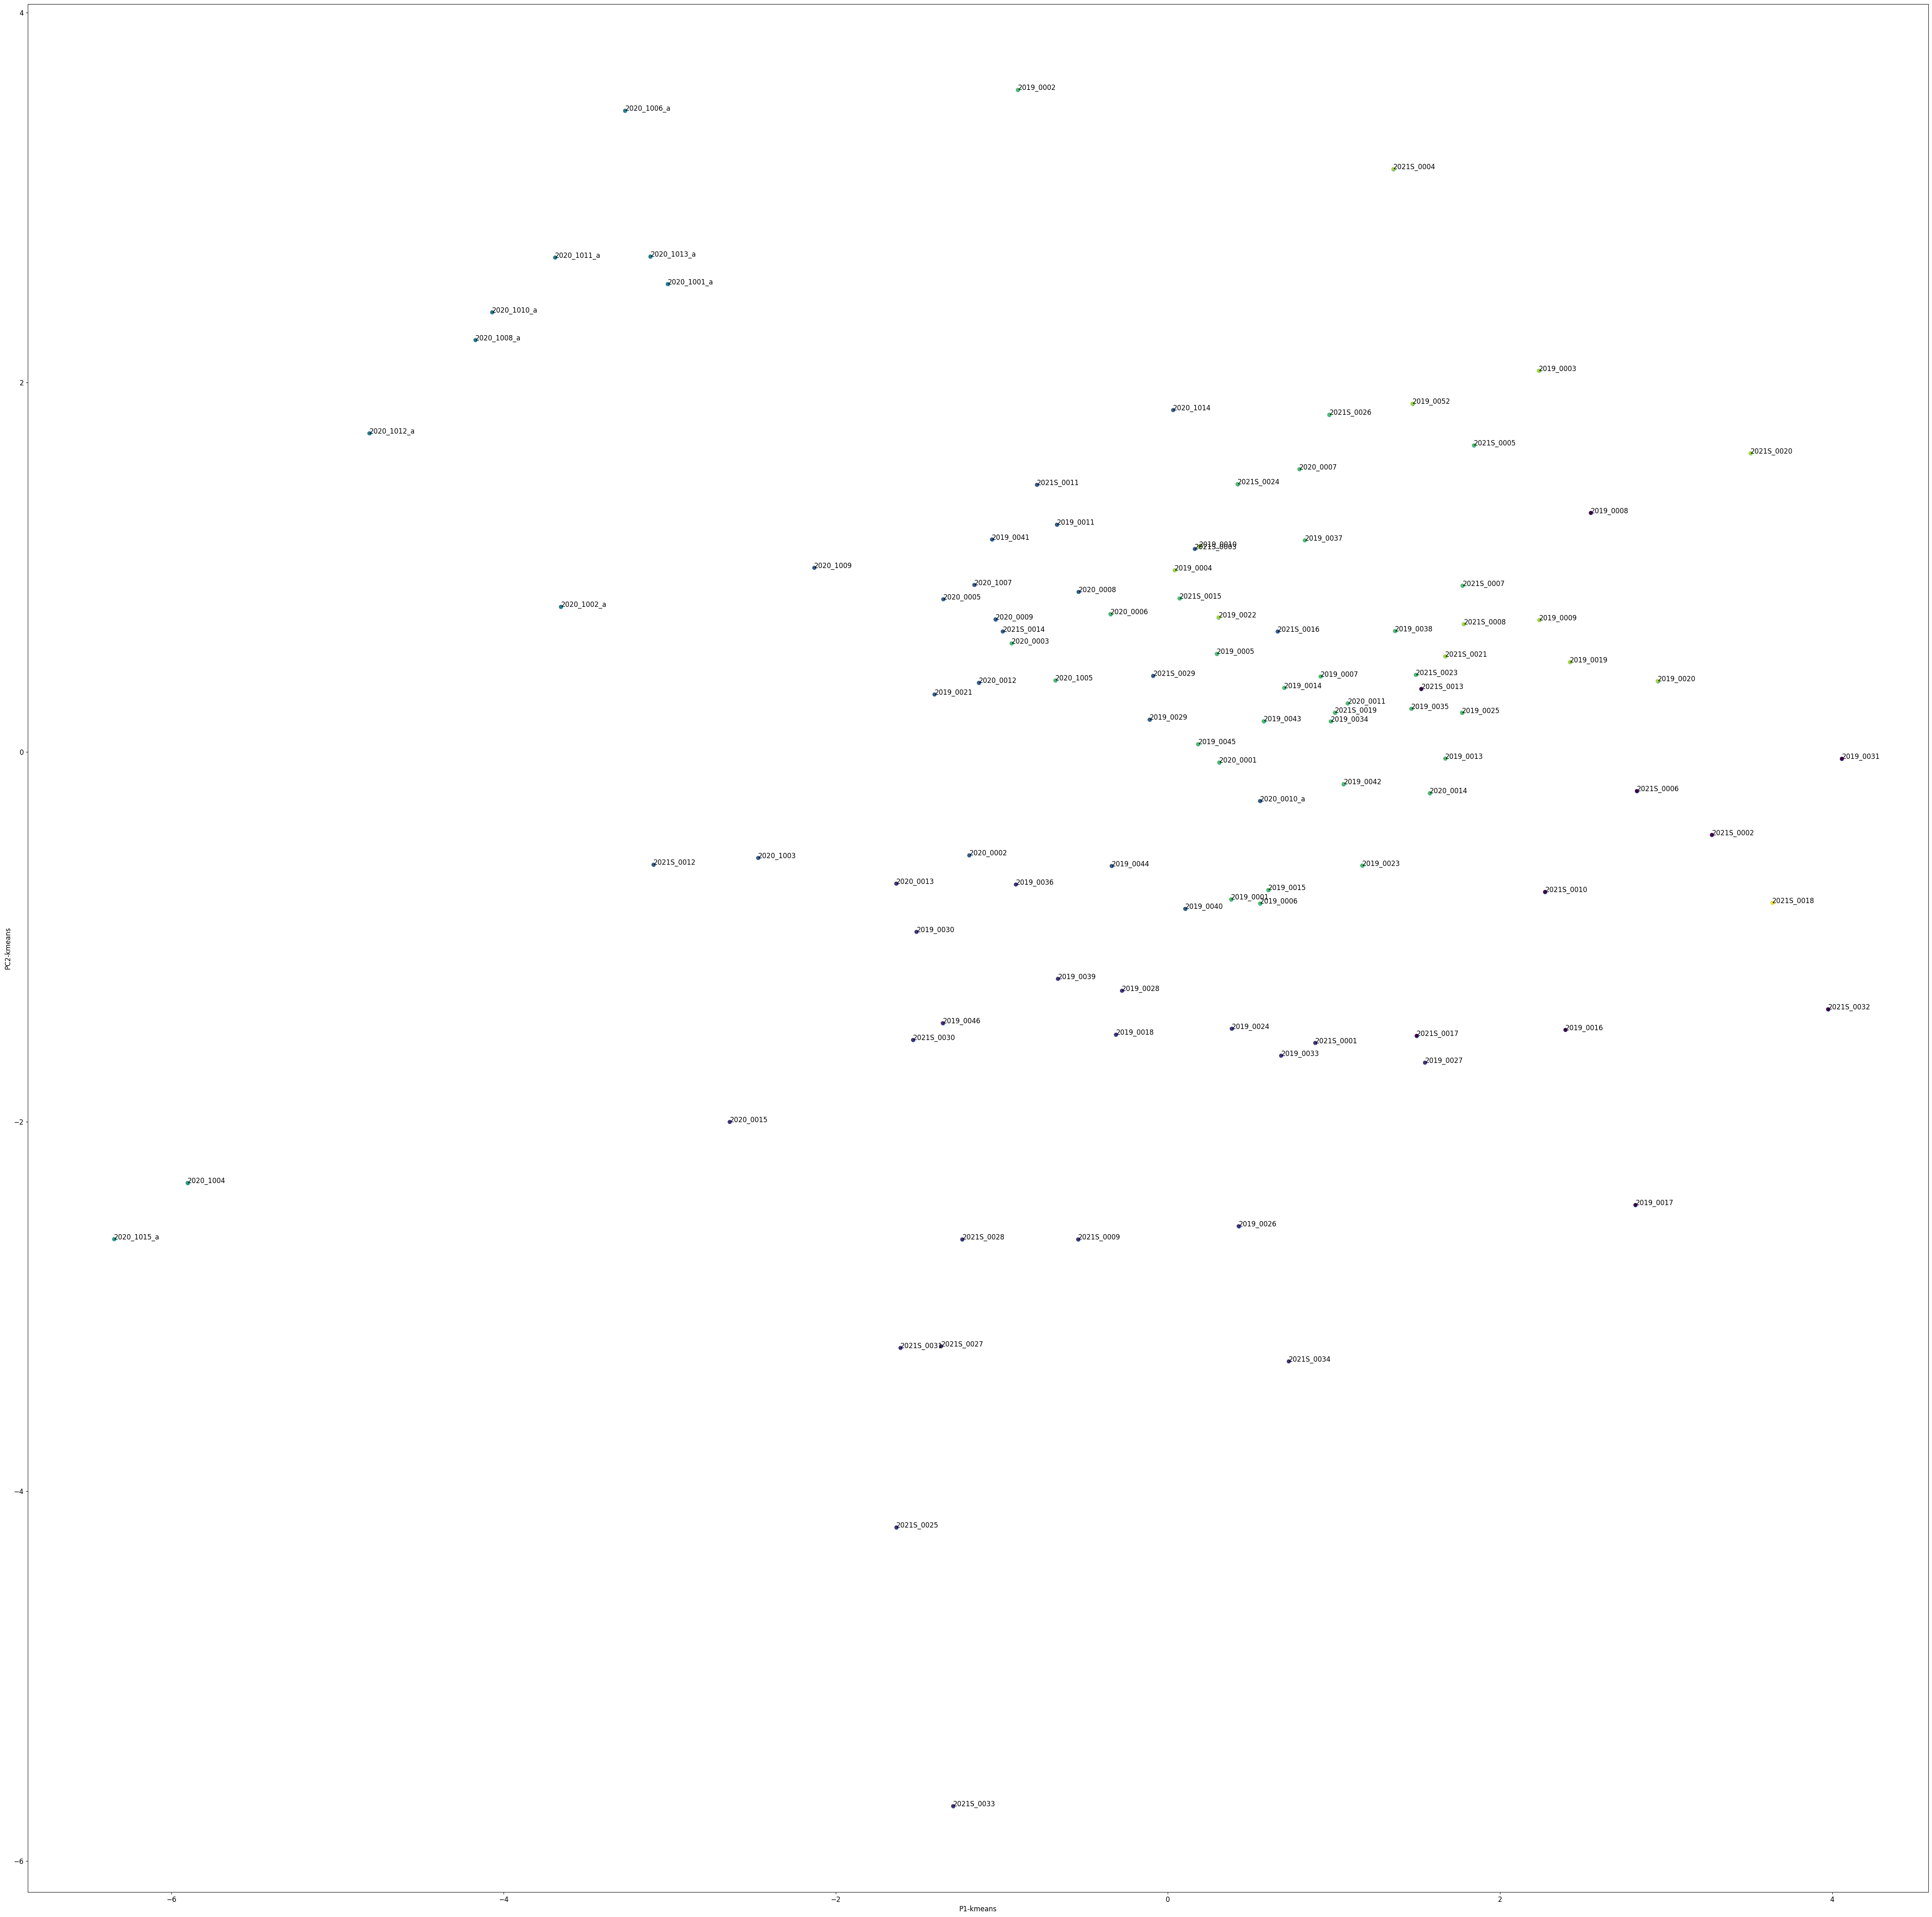

In [ ]:
# Standardlization
from sklearn.preprocessing import StandardScaler

# X改成這樣就可以了
X = data_dum_1.iloc[:, 1:].values #去除了去除了id那一行
print(X)

sc = StandardScaler()
X_train_std = sc.fit_transform(X)

#取最佳pca降維
pcan = PCA(n_components='mle')
X_train_pca = pcan.fit_transform(X_train_std)
print(pcan.explained_variance_ratio_)
plt.figure(figsize=(50,30))
#pcan的結果和pca9.explained_variance_ratio_是一樣的，只是9只顯示了９個
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
#這邊看pc，可以改成 X_train_pca[:, 0], X_train_pca[:, 2]，這樣可以看這樣可以看PC1.3的結果
# 設定target
target = df1['ID'].to_numpy()
for i, target in enumerate (target):
    plt.annotate(target,(X_train_pca[:, 0][i],X_train_pca[:, 1][i]))
plt.xlabel('PC 1')
plt.ylabel('PC 2')


plt.show()

pca9 = PCA(0.9)
X_train_pca = pca9.fit_transform(X_train_std)
print('前90%的的PC值（到PC9）:',pca9.explained_variance_ratio_)
print('特徵向量：',pca9.components_)


from sklearn.cluster import KMeans
plt.figure(figsize=(60,60))

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])

# 設定combine
combine = df1['ID'].to_numpy()
for i, combine in enumerate (combine):
    plt.annotate(combine,(X_train_pca[:, 0][i], X_train_pca[:, 1][i]))

y_pred = KMeans(n_init='auto').fit_predict(X_train_pca) #n_init='auto'自動幫你分群
plt.scatter(X_train_pca[:, 0],  X_train_pca[:, 1], c=y_pred)


plt.xlabel('P1-kmeans')
plt.ylabel('PC2-kmeans')

plt.show()


"\nkmeans =  KMeans(n_init='auto', random_state=0, n_clusters='auto')\ncenters = kmeans.cluster_centers_\nplt.scatter(X_train_pca[:, 0],X_train_pca[:, 1], c='black', s=200, alpha=0.5)\nplt.show()\n\n\nfrom sklearn.cluster import KMeans\nkmeans = KMeans(n_clusters=4)\nkmeans.fit(X)\ny_kmeans = kmeans.predict(X)\n\nplt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')\n\ncenters = kmeans.cluster_centers_\nplt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)\n#get_feature_names_out([y_pred])\n"

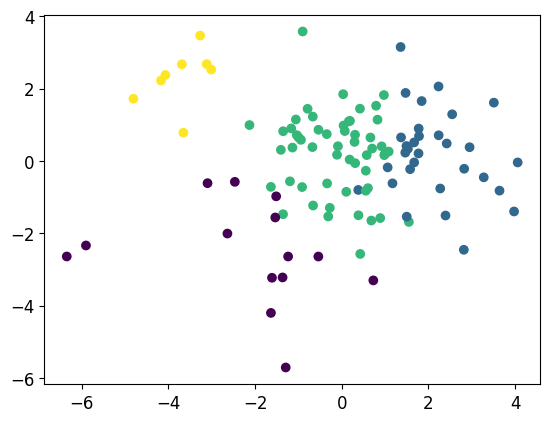

In [ ]:
y_pred = KMeans(n_init='auto', random_state=0, n_clusters = 4).fit_predict(X_train_pca) #n_init='auto'自動幫你分群


plt.scatter(X_train_pca[:, 0],  X_train_pca[:, 1], c=y_pred)
'''
kmeans =  KMeans(n_init='auto', random_state=0, n_clusters='auto')
centers = kmeans.cluster_centers_
plt.scatter(X_train_pca[:, 0],X_train_pca[:, 1], c='black', s=200, alpha=0.5)
plt.show()


from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
#get_feature_names_out([y_pred])
'''

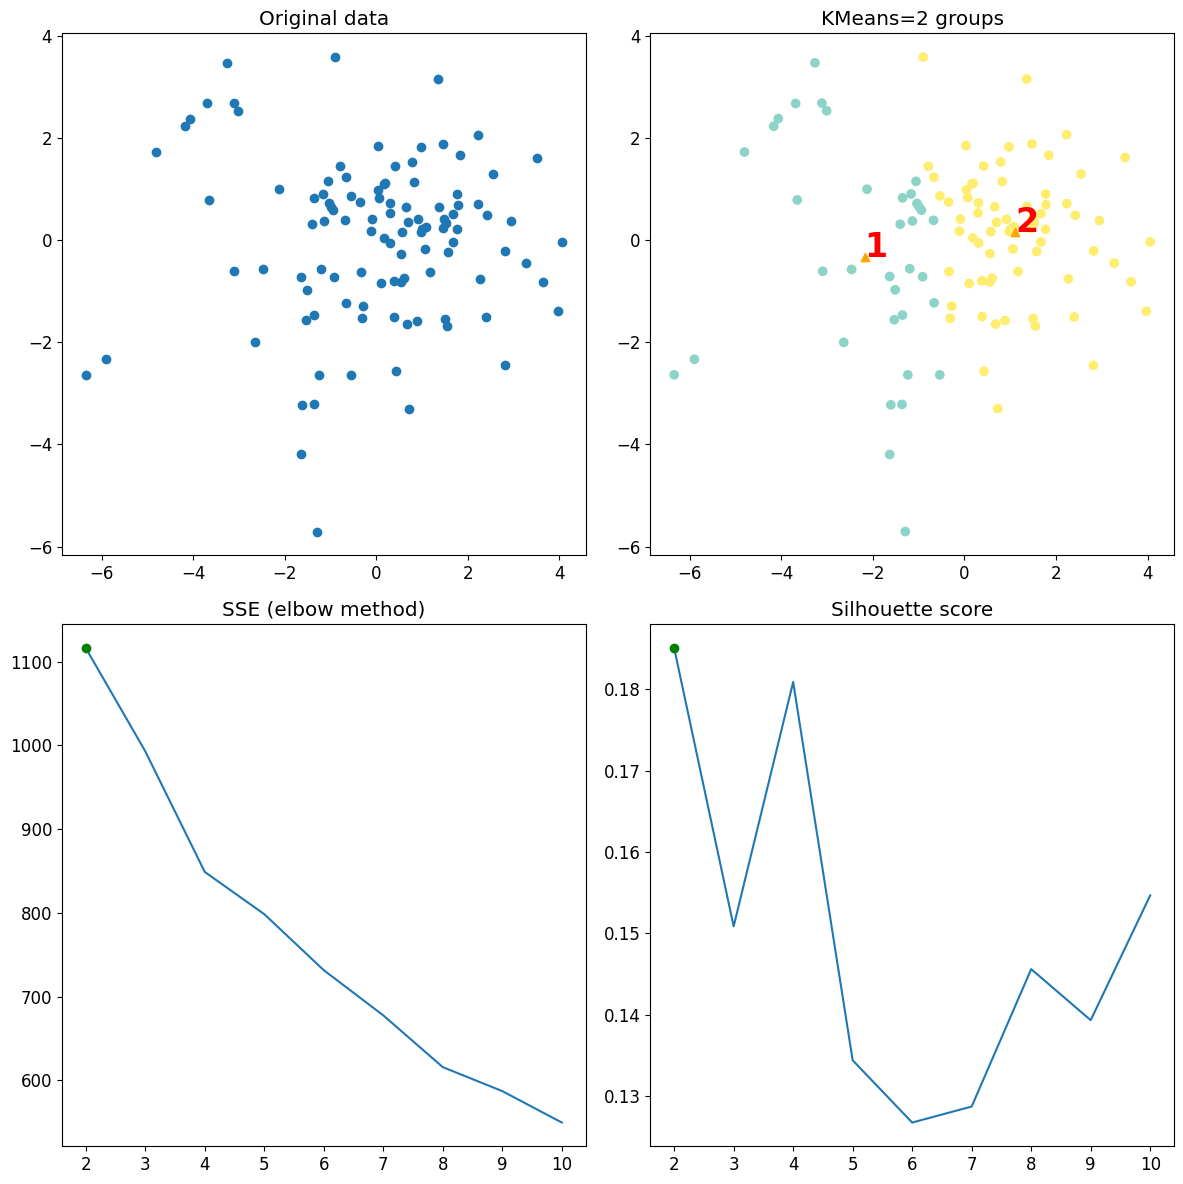

In [ ]:
import matplotlib.pyplot as plt
#from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
#colors = ['red', 'orange', 'yellow', 'green', 'cyan',
#          'blue', 'purple', 'brown', 'grey', 'black']


#y_pred = KMeans(n_init='auto', random_state=0, n_clusters=clusters).fit_predict(X_train_pca) #n_init='auto'自動幫你分群


#plt.scatter(X_train_pca[:, 0],  X_train_pca[:, 1], c=y_pred)

# 產生的資料組數 (10)
clusters = 10
# K 值的範圍 (2~10)
k_range = range(2, clusters + 1)
dx, dy = X_train_pca[:, 0],  X_train_pca[:, 1]
distortions = []
scores = []

# 記錄每種 K 值建出的 KMeans 模型的成效
for i in k_range:
    kmeans = KMeans(n_clusters=i,random_state=0).fit(X_train_pca)
    distortions.append(kmeans.inertia_) # 誤差平方和 (SSE)
    scores.append(silhouette_score(X_train_pca, kmeans.predict(X_train_pca))) # 側影係數
# 找出最大的側影係數來決定 K 值
selected_K = scores.index(max(scores)) + 2
# 重新建立 KMeans 模型並預測目標值
kmeans = KMeans(n_clusters=selected_K).fit(X_train_pca)
new_dy = kmeans.predict(X_train_pca)
# 新分組的資料中心點
centers = kmeans.cluster_centers_
plt.rcParams['font.size'] = 12
plt.figure(figsize=(12, 12))
# 原始資料分組
plt.subplot(221)
plt.title(f'Original data')
plt.scatter(X_train_pca.T[0], X_train_pca.T[1])
#plt.title(f'Original data ({clusters} groups)')
#plt.scatter(X_train_pca.T[0], X_train_pca.T[1], c=dy, cmap=plt.cm.Set1)
# 新資料分組
plt.subplot(222)
plt.title(f'KMeans={selected_K} groups')
plt.scatter(X_train_pca.T[0], X_train_pca.T[1], c=new_dy, cmap=plt.cm.Set3)
plt.scatter(centers.T[0], centers.T[1], marker='^', color='orange')
for i in range(centers.shape[0]): # 標上各分組中心點
    plt.text(centers.T[0][i], centers.T[1][i], str(i + 1),
             fontdict={'color': 'red', 'weight': 'bold', 'size': 24})
# 繪製誤差平方和圖 (手肘法)
plt.subplot(223)
plt.title('SSE (elbow method)')
plt.plot(k_range, distortions)
plt.plot(selected_K, distortions[selected_K - 2], 'go') # 最佳解
# 繪製係數圖
plt.subplot(224)
plt.title('Silhouette score')
plt.plot(k_range, scores)
plt.plot(selected_K, scores[selected_K - 2], 'go') # 最佳解
plt.tight_layout()
plt.savefig("K-Means_results.pdf", format='pdf', bbox_inches='tight')
plt.show()


Text(0, 0.5, 'PC2 (18.45%)')

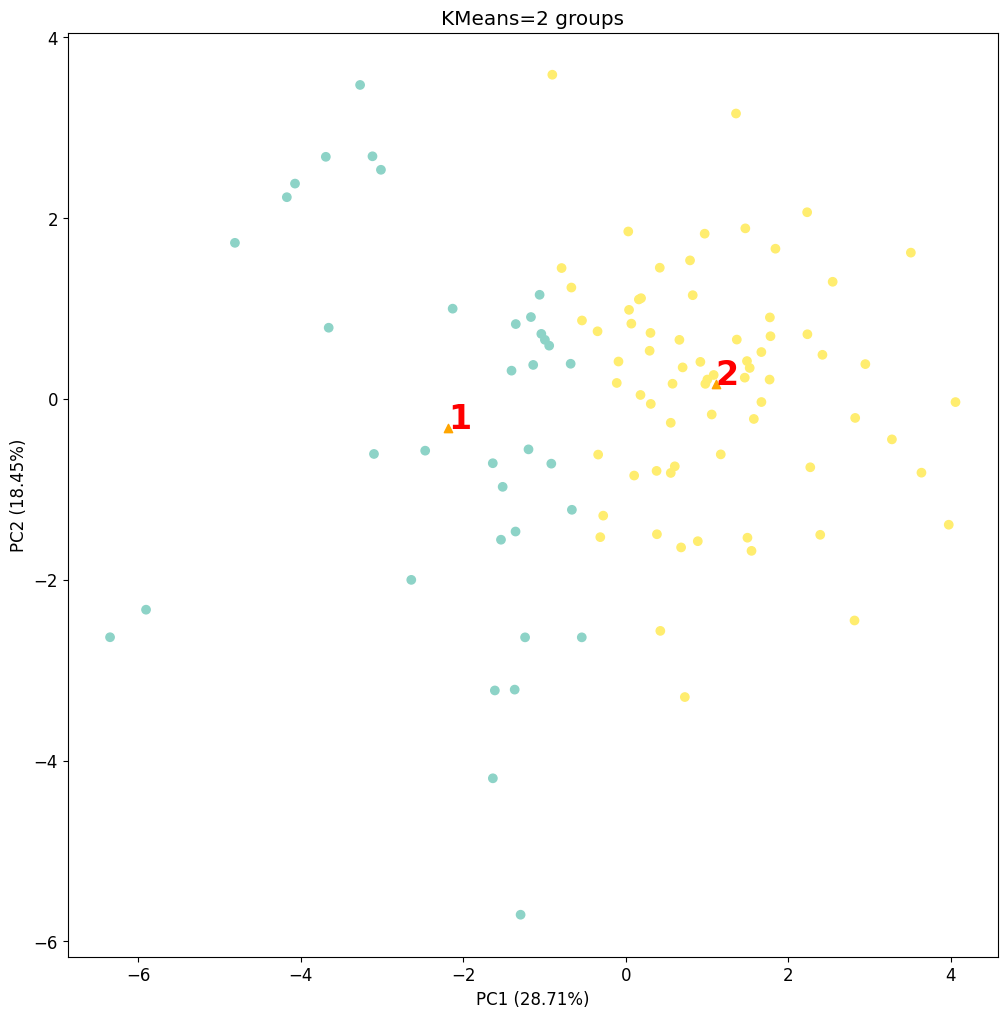

In [ ]:
plt.figure(figsize=(12,12))
plt.title(f'KMeans={selected_K} groups')
plt.scatter(X_train_pca.T[0], X_train_pca.T[1], c=new_dy, cmap=plt.cm.Set3)
plt.scatter(centers.T[0], centers.T[1], marker='^', color='orange')
for i in range(centers.shape[0]): # 標上各分組中心點
    plt.text(centers.T[0][i], centers.T[1][i], str(i + 1),
             fontdict={'color': 'red', 'weight': 'bold', 'size': 24})

plt.xlabel('PC1 (28.71%)')
plt.ylabel('PC2 (18.45%)')

稍微試了下稍微試了下改變random rate。有分成4與7組的結果，肉眼看覺得4組的分的比較好，比較有區分開的感覺

# 作圖

In [ ]:
#create a dataframe from the dataset
df = pd.DataFrame(data = X_train_pca,
                 columns = ["Component 1",
                            "Component 2",
                            "Component 3",
                            "Component 4",
                            "Component 5",
                            "Component 6",
                            "Component 7",
                            "Component 8",
                            "Component 9"
                            ])

#merge this with the data_dum_1 data
data_dum_1 = pd.merge(data_dum_1,
              df,
              left_index=True,
              right_index=True,
              how = "inner")


應該是可以調整參數的

In [ ]:
#set the hyperparmateres for the model with
#the same as in the workshop
#try playing around with them
#how does that affect the outcome?
keep_dims = 2
lrn_rate = 'auto' #5000
#The ‘auto’ option sets the learning_rate to max(N / early_exaggeration / 4, 50)
# where N is the sample size, following [4] and [5].
prp = 40

#create the model
tsne = TSNE(n_components = keep_dims,
            perplexity = prp,
            random_state = 42,
            n_iter = 5000,
            n_jobs = -1)

tsne_df = data_dum_1.loc[:,"Component 1":f"Component 9"].copy()

#fit the model
X_embedded = tsne.fit_transform(tsne_df)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
#create a dataframe from the dataset
df = pd.DataFrame(data = X_embedded,
                 columns = ["Dimension 1",
                            "Dimension 2"])

#merge this with the data_dum_1 data
data_dum_1 = pd.merge(data_dum_1,
              df,
              left_index=True,
              right_index=True,
              how = "inner")

data_dum_1.columns
data_dum_1.head()

,ID,Ch01-1,Ch02,Ch03,Ch04,Ch07,Ch13,Ch16,Ch17,Ch23,...,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Dimension 1_x,Dimension 2_x,Dimension 1_y,Dimension 2_y
0,2019_0001,1,136.0,5.2,47.07,18.9,0.0,8.28,6.96,1.77,...,0.453946,-1.456500,0.378426,-0.041805,2.375088,-0.290525,0.575104,2.544305,0.575104,2.544305
1,2019_0002,1,95.2,3.4,32.87,12.1,0.0,5.68,0.30,1.89,...,-1.702431,0.354009,-0.309503,-0.206775,1.805659,0.409416,3.004786,-2.315623,3.004786,-2.315623
2,2019_0003,1,120.3,7.4,42.57,23.6,21.7,8.66,3.72,1.73,...,2.442074,0.799949,-0.829136,-1.147758,0.181047,-0.103782,-0.174221,4.604216,-0.174221,4.604216
3,2019_0004,1,109.6,4.2,37.93,15.1,10.6,7.92,2.69,1.68,...,0.719601,-0.178516,-0.856481,-0.978653,0.021273,-0.066695,-1.190919,2.513526,-1.190919,2.513526
4,2019_0005,1,134.8,5.1,46.63,16.6,0.0,5.86,1.88,1.70,...,-1.148276,-0.458333,-0.770501,0.384455,0.332848,-0.118095,-0.302764,0.914238,-0.302764,0.914238


作圖

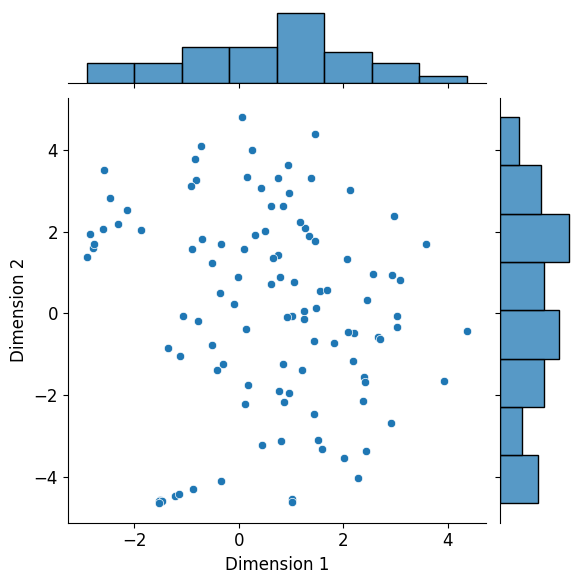

In [ ]:
#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2")

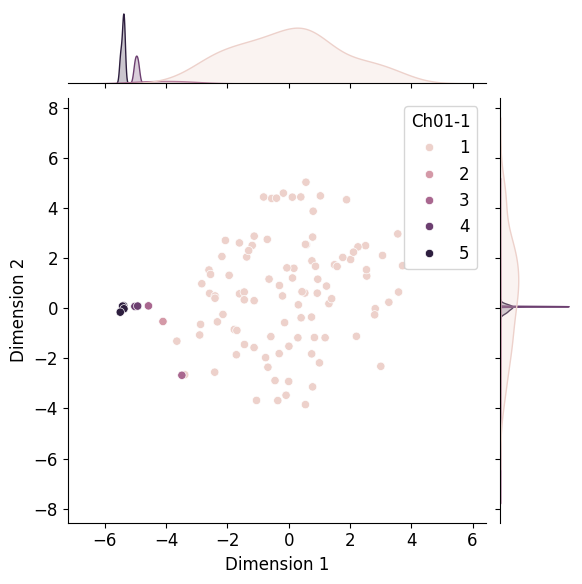

In [ ]:
#plot the result
g = sns.jointplot(data = data_dum_1,
                  x = "Dimension 1",
                  y = "Dimension 2",
                  hue = "Ch01-1")
                  #palette = "Set3")
                  #kind="hist")
#自己設定一下啦
plt.savefig("tsne_Ch01-1.pdf", format='pdf', bbox_inches='tight')

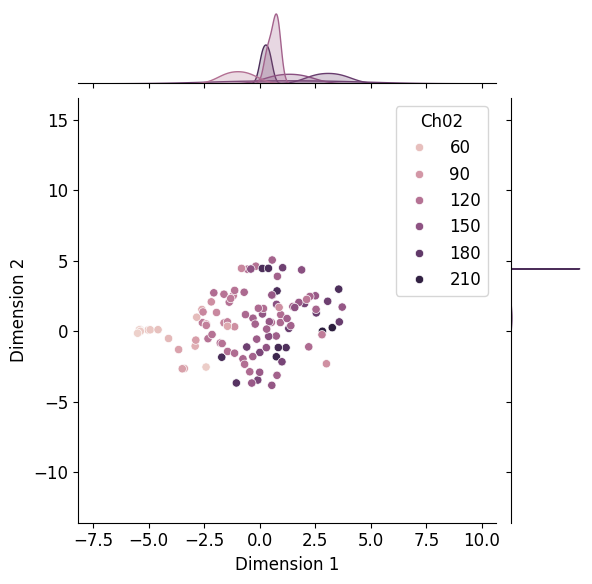

In [ ]:
#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 height = 6,
                 hue = "Ch02")
plt.savefig("tsne_Ch02.pdf", format='pdf', bbox_inches='tight')

In [ ]:
#plot the result
#g = sns.jointplot(data = data_dum_1,
#                 x = "Dimension 1",
#                 y = "Dimension 2",
#                 hue = "Ch02",
#                 kind="hist")

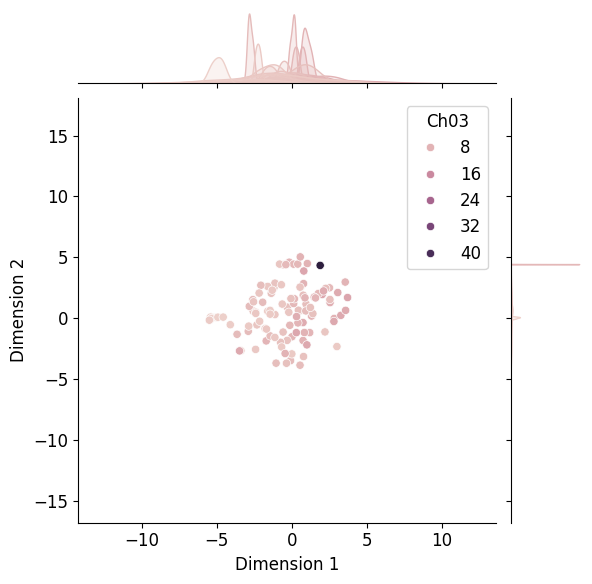

In [ ]:
#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch03")
plt.savefig("tsne_Ch03.pdf", format='pdf', bbox_inches='tight')

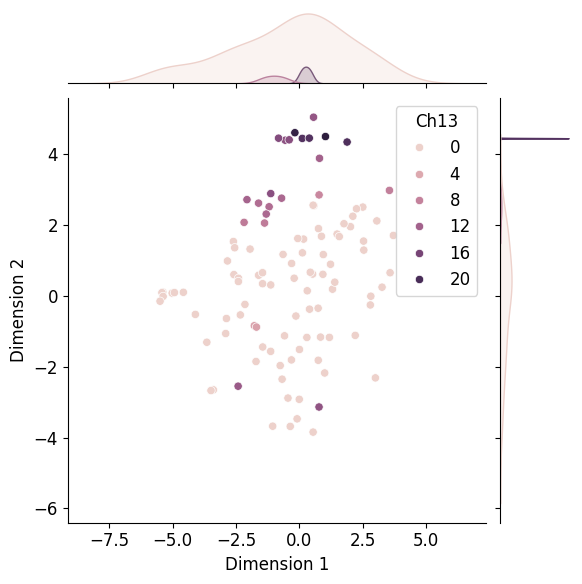

In [ ]:
#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch13")
plt.savefig("tsne_Ch13.pdf", format='pdf', bbox_inches='tight')

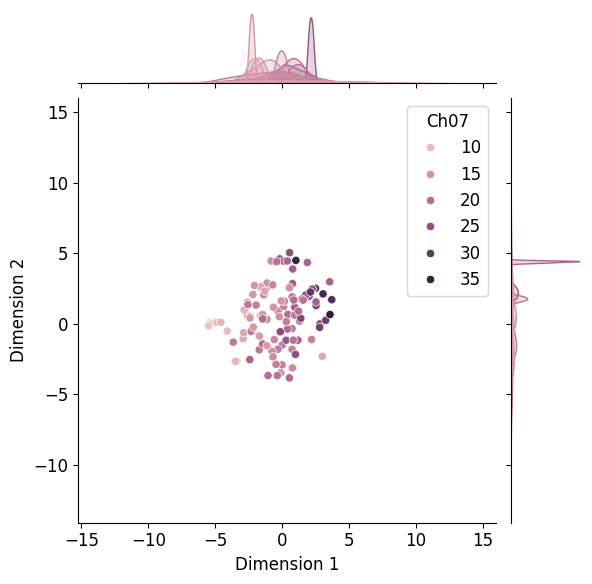

In [ ]:
#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch07")
plt.savefig("tsne_Ch07.pdf", format='pdf', bbox_inches='tight')

# 將圖表加上標籤
無法加載無法加載jointplot上，與seabon object有點問題

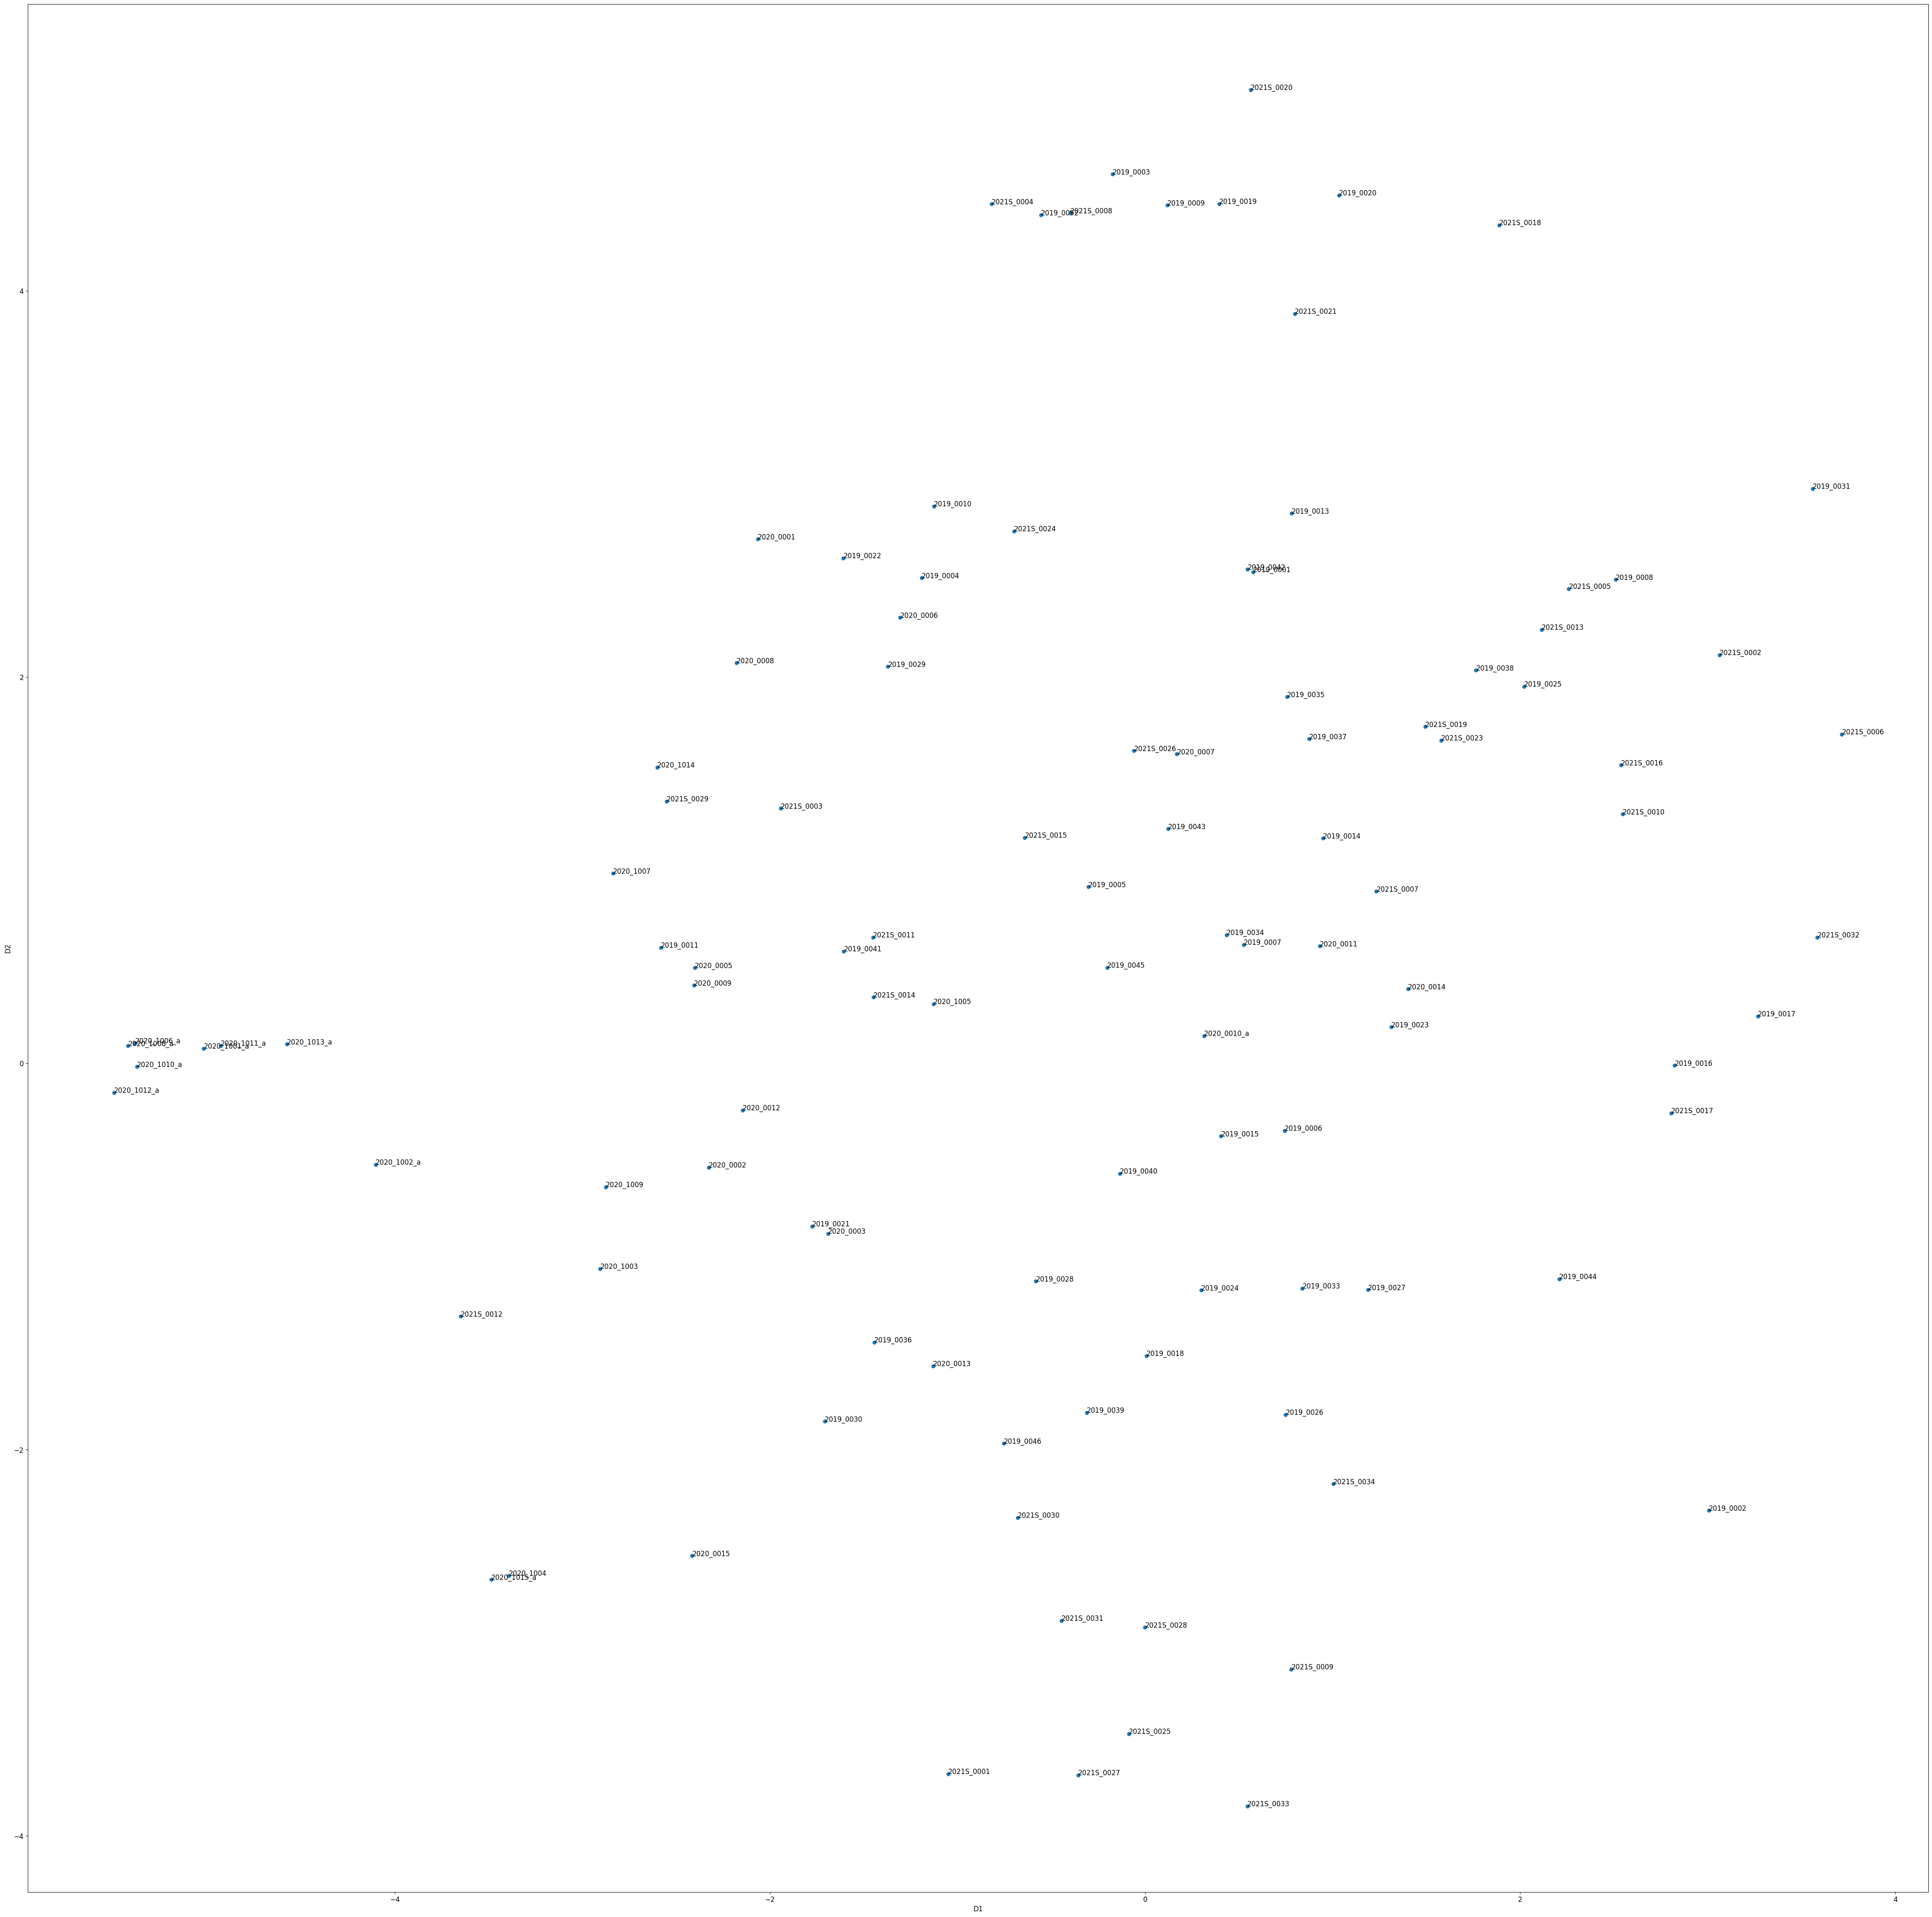

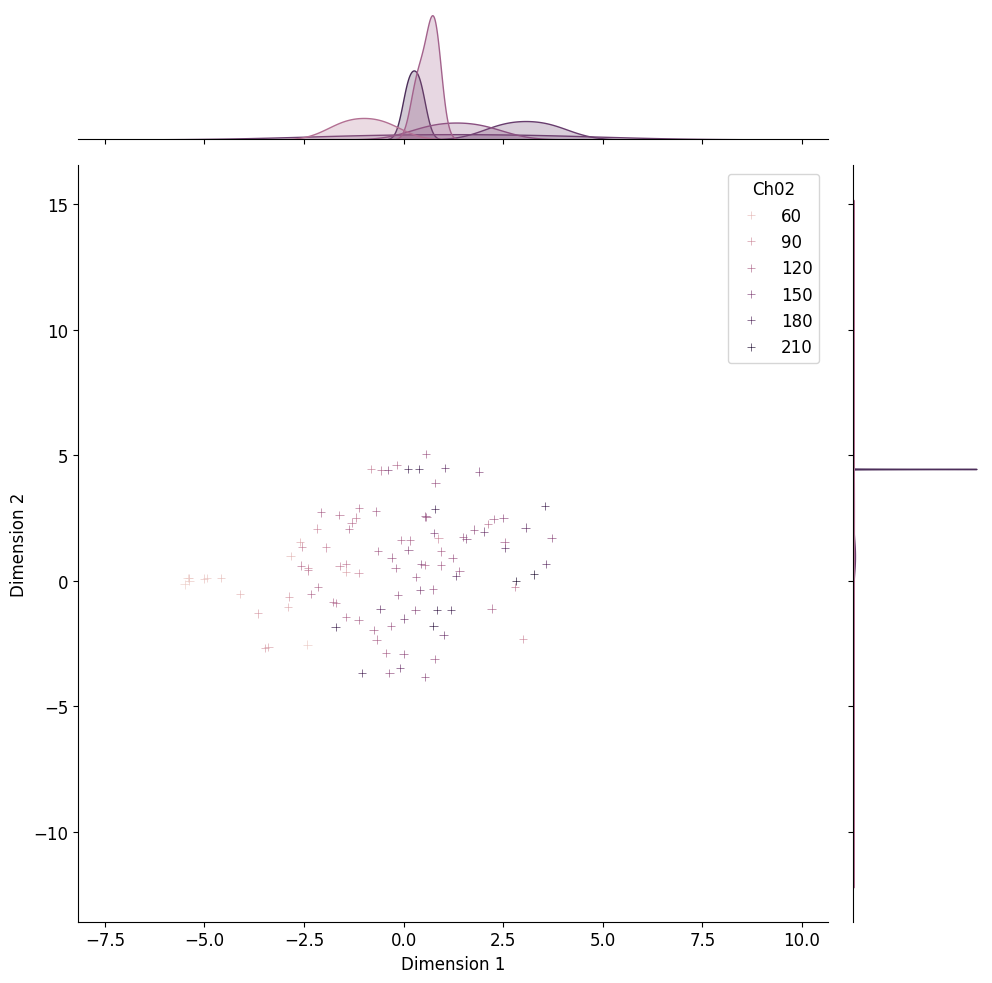

In [ ]:
plt.figure(figsize=(60,60))

plt.scatter(X_embedded[:,0],X_embedded[:,1])

a = X_embedded[:,0]
b = X_embedded[:,1]

# 設定combine
combine = df1['ID'].to_numpy()
for i, combine in enumerate (combine):
    plt.annotate(combine,(a[i],b[i]))

plt.xlabel('D1')
plt.ylabel('D2')

plt.savefig("tsne_results.pdf", format='pdf', bbox_inches='tight')

plt.show()

#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch02",
                 height= 10,
                 marker="+")


做切割種類

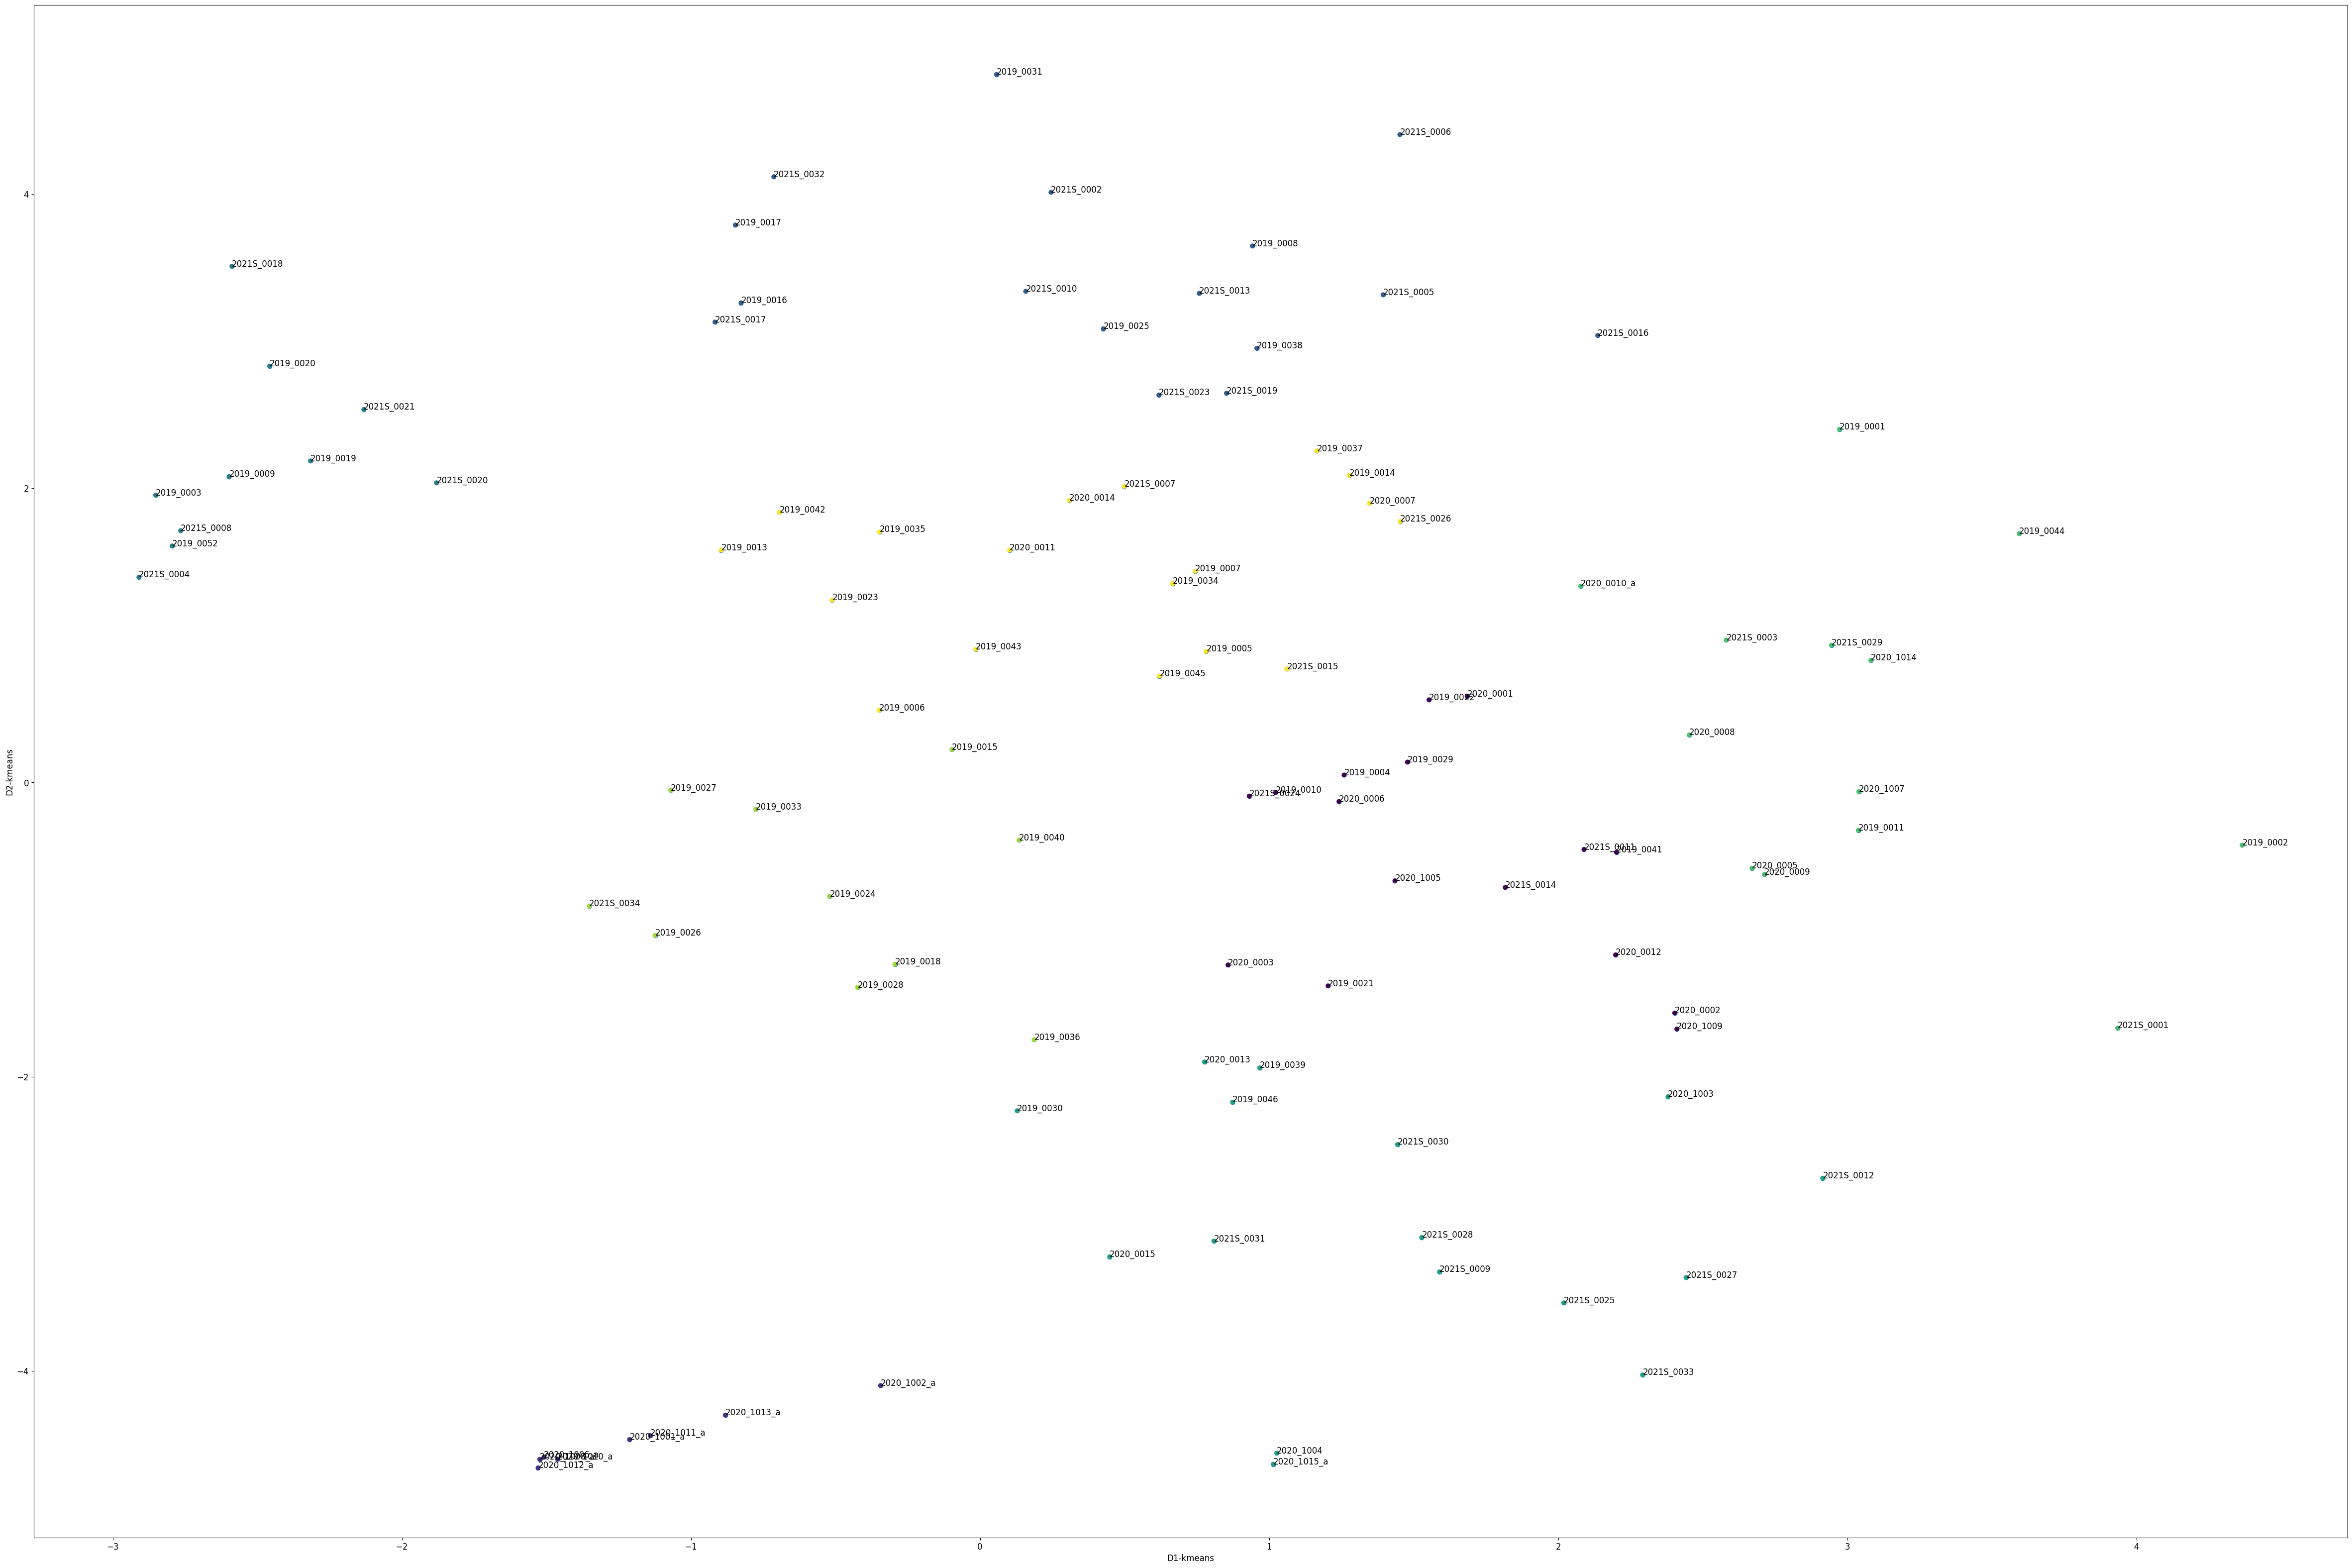

In [ ]:
from sklearn.cluster import KMeans
plt.figure(figsize=(60,40))

plt.scatter(X_embedded[:,0],X_embedded[:,1])

a = X_embedded[:,0]
b = X_embedded[:,1]

# 設定combine
combine = df1['ID'].to_numpy()
for i, combine in enumerate (combine):
    plt.annotate(combine,(a[i],b[i]))

y_pred = KMeans(n_init='auto').fit_predict(X_embedded) #n_init='auto'自動幫你分群
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y_pred)

plt.xlabel('D1-kmeans')
plt.ylabel('D2-kmeans')

plt.show()

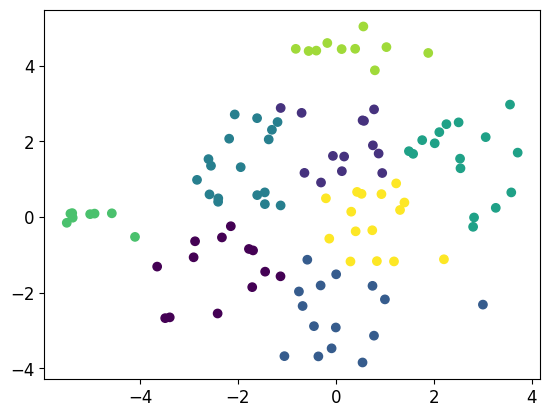

In [ ]:
y_pred = KMeans(n_init='auto',random_state= 0).fit_predict(X_embedded) #n_init='auto'自動幫你分群
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y_pred)
plt.savefig("tsne_K-means.pdf", format='pdf', bbox_inches='tight')
plt.show()

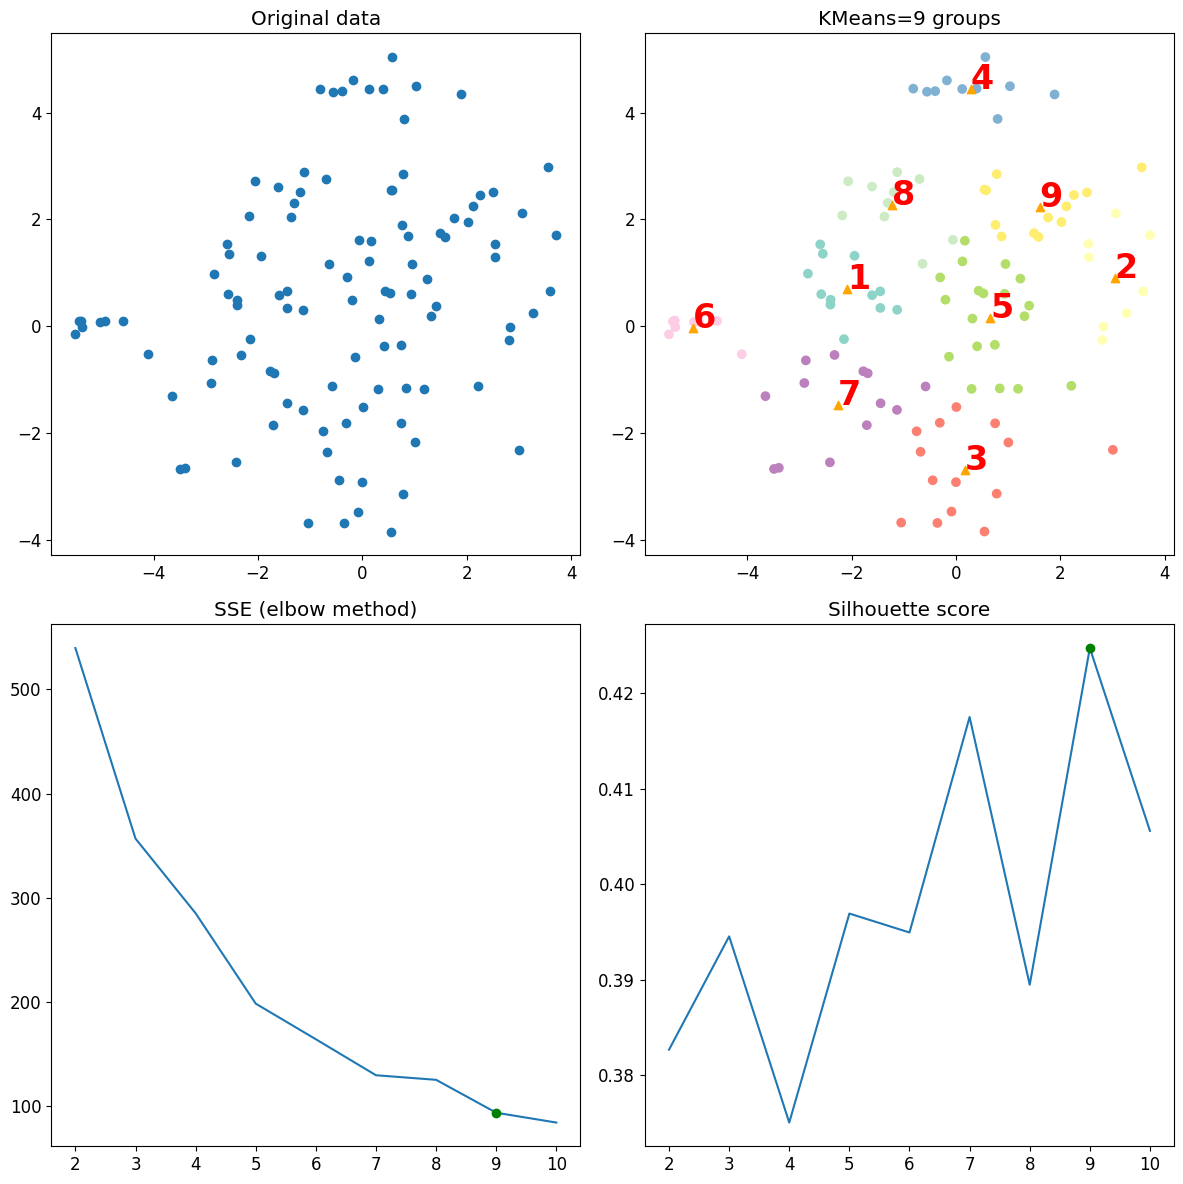

In [ ]:
from sklearn.metrics import silhouette_score

#y_pred = KMeans(n_init='auto',random_state= 0).fit_predict(X_embedded) #n_init='auto'自動幫你分群
#plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y_pred)
#plt.show()

# 產生的資料組數 (10)
clusters = 10
# K 值的範圍 (2~10)
k_range = range(2, clusters + 1)
dx, dy = X_embedded[:,0], X_embedded[:,1]
distortions = []
scores = []

# 記錄每種 K 值建出的 KMeans 模型的成效，random state = 10是6組，9是2組
for i in k_range:
    kmeans = KMeans(n_clusters=i,random_state=10).fit(X_embedded)
    distortions.append(kmeans.inertia_) # 誤差平方和 (SSE)
    scores.append(silhouette_score(X_embedded, kmeans.predict(X_embedded))) # 側影係數
# 找出最大的側影係數來決定 K 值
selected_K = scores.index(max(scores)) + 2
# 重新建立 KMeans 模型並預測目標值
kmeans = KMeans(n_clusters=selected_K).fit(X_embedded)
new_dy = kmeans.predict(X_embedded)
# 新分組的資料中心點
centers = kmeans.cluster_centers_
plt.rcParams['font.size'] = 12
plt.figure(figsize=(12, 12))
# 原始資料分組
plt.subplot(221)
plt.title(f'Original data')
plt.scatter(X_embedded[:,0], X_embedded[:,1]) #X_embedded.T[1], , c=dy, cmap=plt.cm.Set1
#to see the 10 group, please copy under:
# plt.title(f'Original data={clusters} groups')
# plt.scatter(X_embedded.T[:,0], X_embedded.T[:,1], c=dy, cmap=plt.cm.Set1)
# 新資料分組
plt.subplot(222)
plt.title(f'KMeans={selected_K} groups')
plt.scatter(X_embedded.T[0], X_embedded.T[1], c=new_dy, cmap=plt.cm.Set3)
plt.scatter(centers.T[0], centers.T[1], marker='^', color='orange')
for i in range(centers.shape[0]): # 標上各分組中心點
    plt.text(centers.T[0][i], centers.T[1][i], str(i + 1),
             fontdict={'color': 'red', 'weight': 'bold', 'size': 24})
# 繪製誤差平方和圖 (手肘法)
plt.subplot(223)
plt.title('SSE (elbow method)')
plt.plot(k_range, distortions)
plt.plot(selected_K, distortions[selected_K - 2], 'go') # 最佳解
# 繪製係數圖
plt.subplot(224)
plt.title('Silhouette score')
plt.plot(k_range, scores)
plt.plot(selected_K, scores[selected_K - 2], 'go') # 最佳解
plt.tight_layout()
plt.savefig("tsne_K-means_results.pdf", format='pdf', bbox_inches='tight')
plt.show()


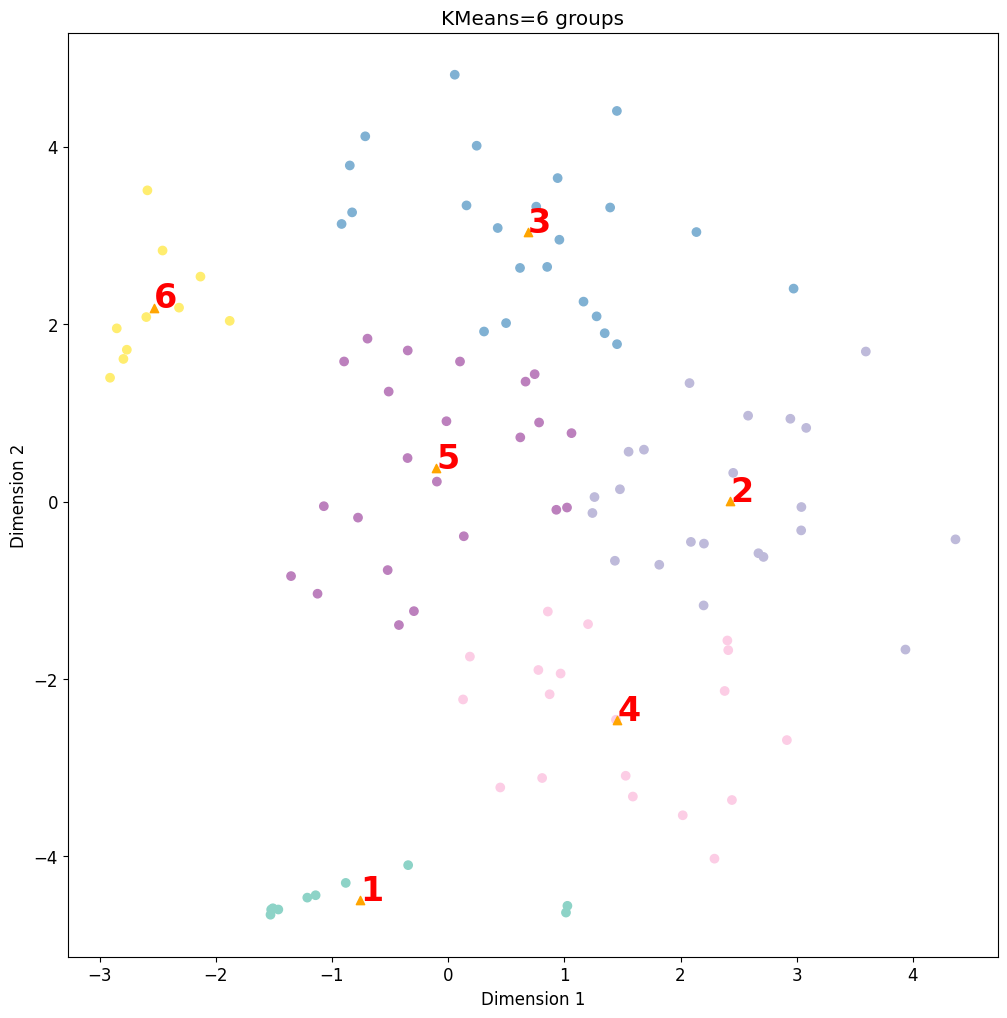

In [ ]:
plt.figure(figsize=(12, 12))
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title(f'KMeans={selected_K} groups')
plt.scatter(X_embedded.T[0], X_embedded.T[1], c=new_dy, cmap=plt.cm.Set3)
plt.scatter(centers.T[0], centers.T[1], marker='^', color='orange')
for i in range(centers.shape[0]): # 標上各分組中心點
    plt.text(centers.T[0][i], centers.T[1][i], str(i + 1),
             fontdict={'color': 'red', 'weight': 'bold', 'size': 24})

# 嘗試將結果加回沒有刪掉東西的表單

In [ ]:
#create a dataframe from the dataset
df = pd.DataFrame(data = X_train_pca,
                 columns = ["Component 1",
                            "Component 2",
                            "Component 3",
                            "Component 4",
                            "Component 5",
                            "Component 6",
                            "Component 7",
                            "Component 8",
                            "Component 9"])

df1 = pd.merge(df1,
              df,
              left_index=True,
              right_index=True,
              how = "inner")
df1.columns

Index(['ID', 'Ch01-1', 'Ch01', 'Ch02', 'Ch03', 'Ch04', 'Ch05', 'Ch06', 'Ch07',
       'Ch08', 'Ch09', 'Ch10', 'Ch11', 'Ch12', 'Ch13', 'Ch14', 'Ch15', 'Ch16',
       'Ch17', 'Ch18', 'Ch19', 'Ch20', 'Ch21', 'Ch22', 'Ch23', 'Ch24', 'Ch25',
       'Ch26', 'Ch27', 'Ch28', 'Ch29', 'Ch30', 'Chcolor', 'Component 1',
       'Component 2', 'Component 3', 'Component 4', 'Component 5',
       'Component 6', 'Component 7', 'Component 8', 'Component 9'],
      dtype='object')

In [ ]:
#set the hyperparmateres for the model with
#the same as in the workshop
#try playing around with them
#how does that affect the outcome?
keep_dims = 2
lrn_rate = 700
prp = 40

#create the model
tsne = TSNE(n_components = keep_dims,
            perplexity = prp,
            random_state = 42,
            n_iter = 5000,
            n_jobs = -1)

tsne_df = data_dum_1.loc[:,"Component 1":f"Component 9"].copy()

#fit the model
X_embedded = tsne.fit_transform(tsne_df)

In [ ]:
#create a dataframe from the dataset
df = pd.DataFrame(data = X_embedded,
                 columns = ["Dimension 1",
                            "Dimension 2"])

#merge this with the df1 data
df1 = pd.merge(df1,
              df,
              left_index=True,
              right_index=True,
              how = "inner")
df1.columns

Index(['ID', 'Ch01-1', 'Ch01', 'Ch02', 'Ch03', 'Ch04', 'Ch05', 'Ch06', 'Ch07',
       'Ch08', 'Ch09', 'Ch10', 'Ch11', 'Ch12', 'Ch13', 'Ch14', 'Ch15', 'Ch16',
       'Ch17', 'Ch18', 'Ch19', 'Ch20', 'Ch21', 'Ch22', 'Ch23', 'Ch24', 'Ch25',
       'Ch26', 'Ch27', 'Ch28', 'Ch29', 'Ch30', 'Chcolor', 'Component 1',
       'Component 2', 'Component 3', 'Component 4', 'Component 5',
       'Component 6', 'Component 7', 'Component 8', 'Component 9',
       'Dimension 1', 'Dimension 2'],
      dtype='object')

作圖

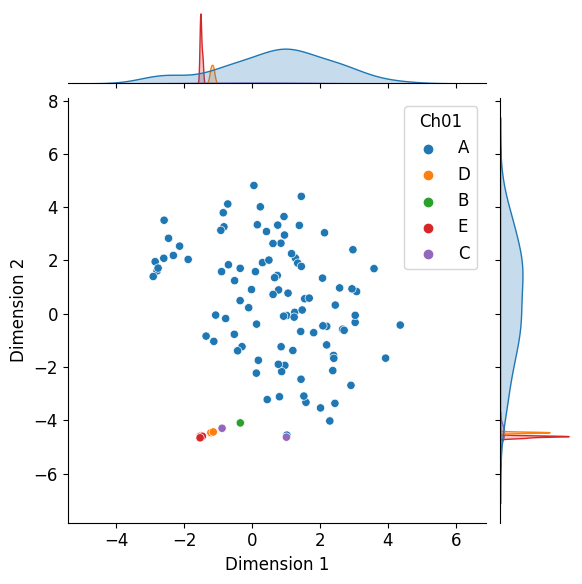

In [ ]:
#plot the result
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch01") #分岔數目


ValueError: Could not interpret value `Dimension 1` for `x`. An entry with this name does not appear in `data`.

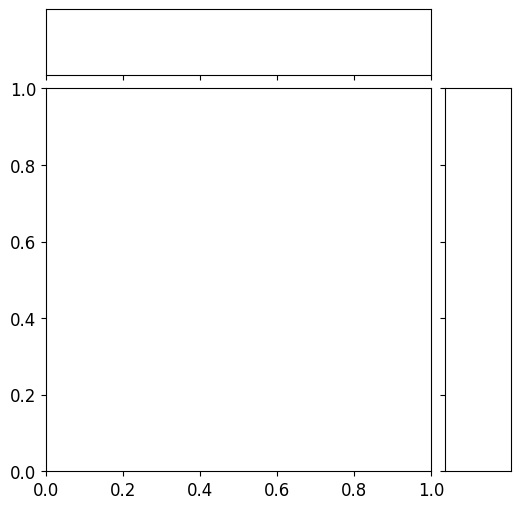

In [ ]:
#plot the result
hue_order = ['Y', 'R', 'B']
h = sns.jointplot(data = df1,
                  x="Component 1",
                  y="Component 2",
                 hue = "Chcolor",
                 palette={'B': 'dimgray','R':'indianred' ,'Y':'gold'},
                 hue_order = hue_order
                  ) #color
plt.savefig("tsne_color.pdf", format='pdf', bbox_inches='tight')

ValueError: Could not interpret value `Dimension 1` for `x`. An entry with this name does not appear in `data`.

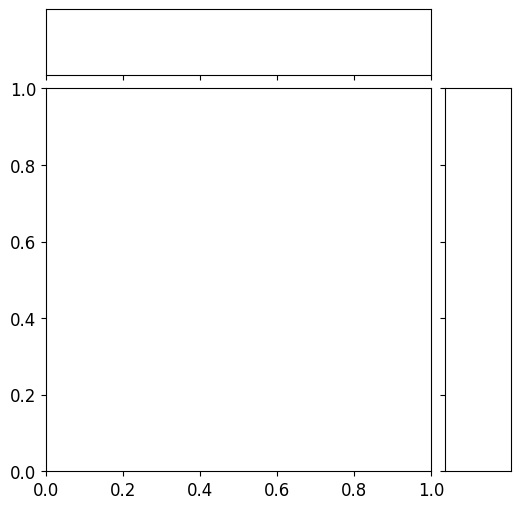

In [ ]:
#plot the result
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch06") #

In [ ]:
#plot the result
'''
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch01") #分岔數目

'''

'\nh = sns.jointplot(data = df1,\n                 x = "Dimension 1",\n                 y = "Dimension 2",\n                 hue = "Ch01") #分岔數目\n\n'

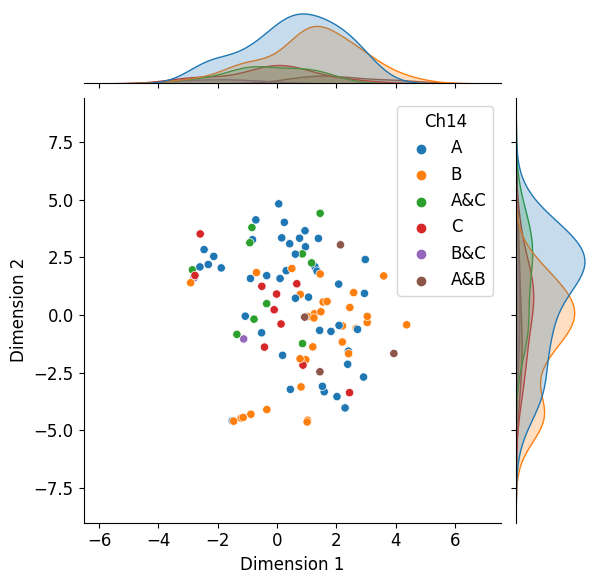

In [ ]:
#plot the result
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch14") #穀碼形狀


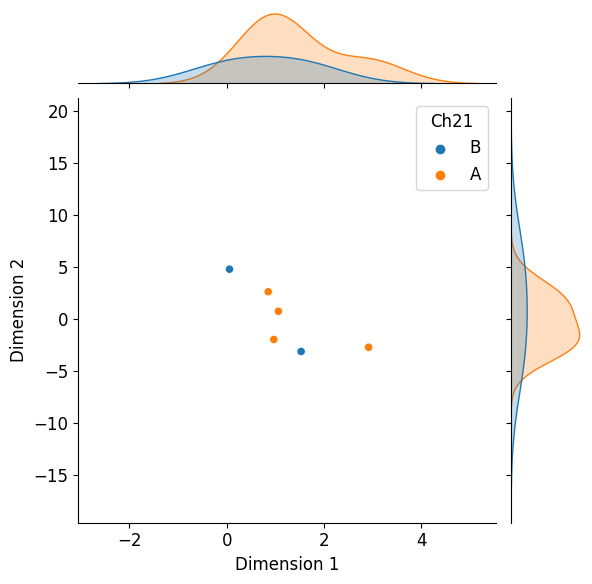

In [ ]:
#plot the result
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch21") #混色

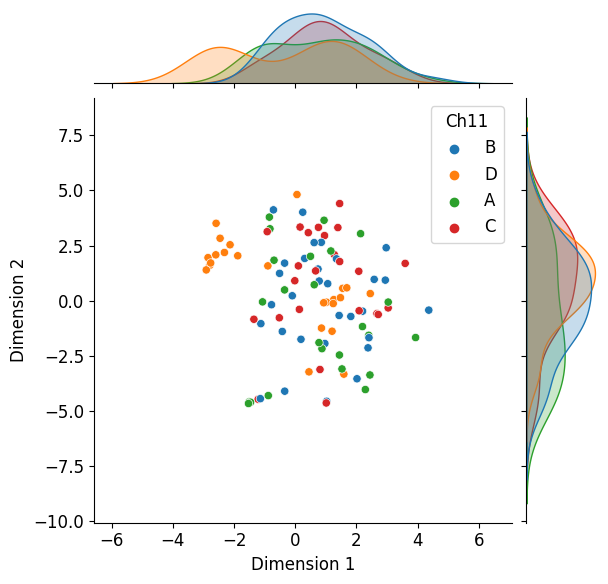

In [ ]:
#plot the result
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch11") #尖端

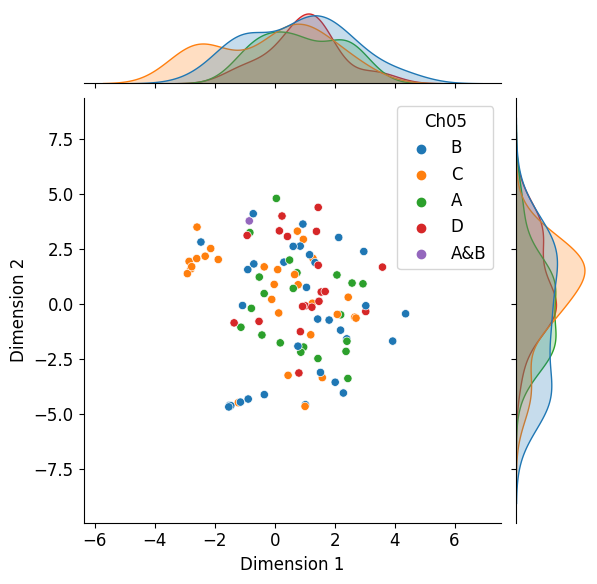

In [ ]:
#plot the result
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch05") #果穗形狀

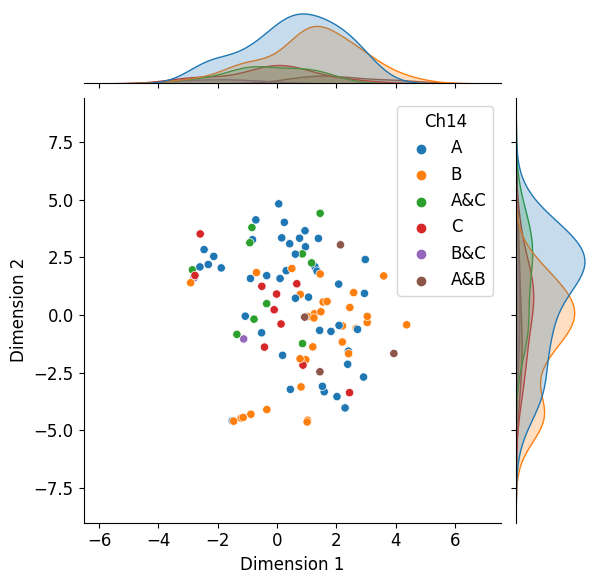

In [ ]:
#plot the result
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch14")

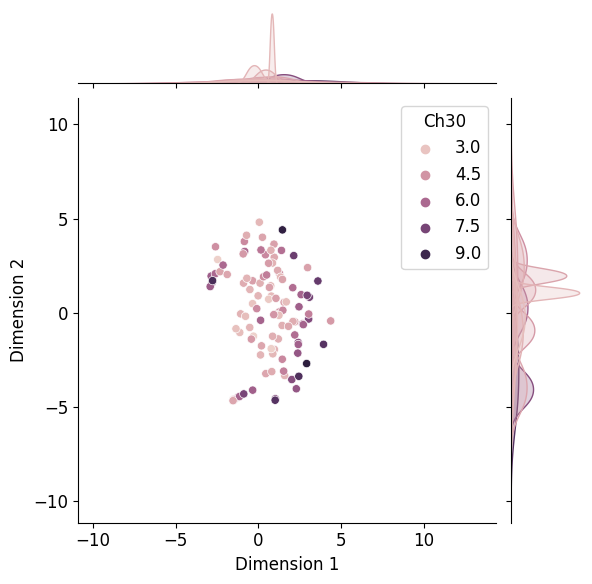

In [ ]:
#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Ch30")#剛毛長

In [ ]:
#plot the result，以ID標記
'''
h = sns.jointplot(data = df1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "ID")

'''

'\nh = sns.jointplot(data = df1,\n                 x = "Dimension 1",\n                 y = "Dimension 2",\n                 hue = "ID") \n\n'

# 以下參考

In [ ]:
# https://towardsdatascience.com/dimensionality-reduction-with-pca-and-t-sne-in-python-c80c680221d
# https://github.com/UCL-DSS/Dimensionality_reduction/blob/main/.ipynb_checkpoints/Problems-checkpoint.ipynb
#import the method
from sklearn.manifold import TSNE
#set the hyperparmateres
keep_dims = 2 #mle? 不可，維度不能大於三
lrn_rate = 700
prp = 40
#extract the data as a cop
tsnedf = X
#creae the model
tsne = TSNE(n_components = keep_dims,
            perplexity = prp,
            random_state = 42,
            n_iter = 5000,
            n_jobs = -1)
#apply it to the data
X_dimensions = tsne.fit_transform(tsnedf)
#check the shape
X_dimensions.shape

/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


(107, 2)

ValueError: ignored

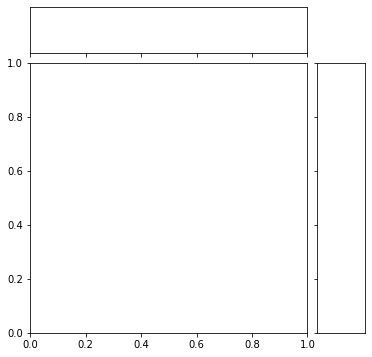

In [ ]:
#create a dataframe from the dataset
tsnedf_res = pd.DataFrame(data = X_dimensions,
                         columns = ["Dimension 1",
                                "Dimension 2"])

#merge this with the NBA data
data_dum_1 = pd.merge(data_dum_1,
              tsnedf_res,
              left_index=True,
              right_index=True,
              how = "inner")


#plot the result
g = sns.jointplot(data = data_dum_1,
                 x = "Dimension 1",
                 y = "Dimension 2",
                 hue = "Pos")



In [ ]:
tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(x)
#mle? 不可，維度不能大於三

In [ ]:
df = pd.DataFrame()
df["y"] = y
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]

sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                palette=sns.color_palette("hls", 3),
                data=df).set(title="Iris data T-SNE projection")